# Generic Imports

Run these cells first to set up python and import basic libraries like numpy and pandas.

In [101]:
import sys

assert sys.version_info >= (3, 10)

Scikit=Learn >= 1.6.1

In [102]:
from packaging.version import Version
import sklearn

assert Version(sklearn.__version__) >= Version("1.6.1")

In [103]:
from pathlib import Path
from enum import Enum
from typing import List, Tuple, Dict, Optional

# Loading the data
import tarfile
import urllib.request

# Data science
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from pandas.api.types import is_numeric_dtype

from pandas.plotting import scatter_matrix

Default font sizes for matplotlib to plot pretty figures:

In [104]:

plt.rc('font', size=12)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=12)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

# Scikit-Learn Imports

Run these imports to load all the scikit classes, models and utility functions you'll use throughout the code.

In [105]:

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectFromModel
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit, GridSearchCV, RandomizedSearchCV
from sklearn.pipeline import Pipeline, FunctionTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from scipy.stats import uniform, loguniform

Displaying the structure of the pipelines as diagrams

In [106]:
sklearn.set_config(display="diagram")

# Utility functions

### Loading the data

Loading a generic file from the folder in the repo where this data is stored.

ColumnNamespace is a class which can be used to reference the names of the columns and have some helpful automcomplete features in the IDE.

In [119]:
def load_data(file_name: str) -> pd.DataFrame:
    data_root = "https://raw.githubusercontent.com/Ray-Man05/handson-mlp-main/refs/heads/main/data/Kaggle/"
    ext = ".csv"
    file_name = file_name + ext if not file_name.endswith(ext) else file_name
    
    try:
        df = pd.read_csv(data_root + file_name)
        return df
    except Exception as e:
        print(e)

def load_housing_data() -> pd.DataFrame:
    return load_data("train.csv")

class ColumnNamespace:
    """Simple namespace object for column names with autocomplete support"""
    def __init__(self, df):
        for col in df.columns:
            setattr(self, col, col)
    
    def __repr__(self):
        return f"Columns({', '.join(self.__dict__.keys())})"

In [124]:
housing_raw = load_housing_data()
housing_full = housing_raw.copy()
cols = ColumnNamespace(housing_full)
housing = housing_full.drop(cols.SalePrice, axis=1)

### Plotting

In [ ]:
def square_matrix_plots(attributes: List[str], df: pd.DataFrame = None, figsize: int = 20) -> None:
    
    if df is None:
        df = housing_raw.copy()
        
    plt.figure(figsize=(figsize, figsize))
        
    # Calculate correlations
    corr_matrix = df[attributes].corr()

    # Create pairplot
    g = sns.pairplot(df[attributes], 
                        diag_kind='kde',
                        plot_kws={'alpha': 0.6, 's': 20},
                        height=2.5)

    # Add correlation coefficients to upper triangle
    for i, j in zip(*np.triu_indices_from(g.axes, 1)):
        corr = corr_matrix.iloc[i, j]
        g.axes[i, j].annotate(f'ρ={corr:.2f}', 
                                xy=(0.5, 0.9), 
                                xycoords='axes fraction',
                                ha='center', fontsize=9,
                                bbox=dict(boxstyle="round,pad=0.3", 
                                        facecolor="white", alpha=0.8))

    plt.suptitle(f'Pair Plot with Correlation Coefficients for:\n{attributes}', y=1.02)
    plt.tight_layout()
    plt.show()

def full_square_correlation_matrix(df: pd.DataFrame = None) -> None:

    if df is None:
        df = housing_raw.copy()

    # Get only numeric columns
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    correlation = df[numeric_cols].corr()

    # Create heatmap
    plt.figure(figsize=(24, 24))
    sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0, 
                square=True, fmt='.2f', linewidths=1, 
                annot_kws={"size": 8}, cbar_kws={"shrink": 0.8})
    plt.title('Correlation Matrix of Numeric Features')
    plt.tight_layout()
    plt.show()
    
def scatter_plot_colormap(x: str = 'GrLivArea', y: str = 'SalePrice', hue: str = '', xlabel: str = 'Living Area', ylabel: str = 'Sale Price', cbar_title: str = 'Overall Quality', 
                          df: pd.DataFrame = None, palette: str = 'viridis', alpha: float = 0.6, plot_size: int = 10):
    
    if df is None:
        df = housing_raw.copy()
        
    sns.set_style("whitegrid")

    plt.figure(figsize=(plot_size, plot_size))

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

    if hue:
        # Scatter plot with color 
        ax=sns.scatterplot(data=df, x=x, y=y, 
                            hue= hue, palette=palette, 
                            alpha=alpha, edgecolor='black', linewidth=0.1, legend=False)
        norm = plt.Normalize(df[hue].min(), df[hue].max())
        sm = plt.cm.ScalarMappable(cmap=palette, norm=norm)
        sm.set_array([])

        # Add colorbar
        cbar = plt.colorbar(sm, ax=ax)
        cbar.set_label(cbar_title)
    else:
        ax=sns.scatterplot(data=df, x=x, y=y, alpha=alpha, edgecolor='black', linewidth=0.1, legend=False)


    plt.show()
    
    
def box_plot(attribute: str, target: str = cols.SalePrice, df: pd.DataFrame = None):

    if df is None:
        df = housing_raw.copy()

    # Fill NaN with explicit string
    df[attribute] = df[attribute].fillna('Missing')

    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df, x=attribute, y=target)
    plt.xticks(rotation=45)
    plt.show()

        

### DataFrame info

Allows to quickly get lists of features depending on their data type (numeric/non numeric), and whether the features are defined to have meaningful NaN values (e.g., NA in PoolQc means the house has no pool).

Can also print out this information alongside a count of how many rows have a null value in that column.

It creates an `info_data` dataframe which contains the following columns: `["FeatureName", "DataType", "ContainsNaN", "NaNisMeaningful", "NumberOfNaN"]`.

This class does present some redunduncy, but the point is to quickly access this sort of metadata and have a clear overview of it.

In [ ]:
class DataFrameInfo:
    """
    A utility class for analyzing DataFrame columns and their properties.
    
    Parameters
    ----------
    df : pd.DataFrame
        The DataFrame to analyze
    features_where_null_is_meaningful : list, optional
        List of column names where NaN represents meaningful absence (not an error)
    """
    
    def __init__(self, df: pd.DataFrame = None, target_col:str = cols.SalePrice, features_where_null_is_meaningful: List[str] = None):
        if df is None:
            self.df = housing_raw.copy()
        else:
            self.df = df.copy()
        if target_col is not None and target_col in self.df.columns:
            self.df = self.df.drop(target_col, axis=1)
    
        self.meaningful_null_features = set(features_where_null_is_meaningful or [])
        self.info_df = self._build_info_dataframe()
    
    def _build_info_dataframe(self):
        """Construct the summary DataFrame with column metadata."""
        info_data = []
        
        for col in self.df.columns:
            feature_name = col
            data_type = str(self.df[col].dtype)
            contains_nan = self.df[col].isna().any()
            num_nan = self.df[col].isna().sum()
            nan_is_meaningful = col in self.meaningful_null_features
            
            info_data.append({
                'FeatureName': feature_name,
                'DataType': data_type,
                'ContainsNaN': contains_nan,
                'NaNisMeaningful': nan_is_meaningful,
                'NumberOfNaN': num_nan
            })
        
        return pd.DataFrame(info_data)
    
    def problematic_columns(self, with_counts: bool = False):
        """Return columns of any data type with NaN where NaN is NOT meaningful and that have at least one NaN value."""
        mask = self.info_df['ContainsNaN'] & ~self.info_df['NaNisMeaningful']
        cols = self.info_df.loc[mask, 'FeatureName'].tolist()
        if with_counts:
            counts = self.info_df.loc[mask, 'NumberOfNaN'].tolist()
            return list(zip(cols, counts))
        return cols
    
    def problematic_num_columns(self, with_counts: bool = False):
        """Return numeric columns with problematic NaN values. (NaN does NOT represent the absence of the feature)  and that have at least one NaN value"""
        prob_cols = set(self.problematic_columns())
        num_cols = set(self.num_columns())
        result_cols = list(prob_cols & num_cols)
        if with_counts:
            counts_dict = dict(zip(self.info_df['FeatureName'], self.info_df['NumberOfNaN']))
            return [(col, counts_dict[col]) for col in result_cols]
        return result_cols
    
    def problematic_non_num_columns(self, with_counts: bool = False):
        """Return non-numeric columns with problematic NaN values. (NaN does NOT represent the absence of the feature)  and that have at least one NaN value """
        prob_cols = set(self.problematic_columns())
        non_num_cols = set(self.non_num_columns())
        result_cols = list(prob_cols & non_num_cols)
        if with_counts:
            counts_dict = dict(zip(self.info_df['FeatureName'], self.info_df['NumberOfNaN']))
            return [(col, counts_dict[col]) for col in result_cols]
        return result_cols
    
    def num_columns(self, with_counts: bool = False):
        """Return all numeric column names."""
        numeric_dtypes = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
        mask = self.info_df['DataType'].isin(numeric_dtypes)
        cols = self.info_df.loc[mask, 'FeatureName'].tolist()
        if with_counts:
            counts = self.info_df.loc[mask, 'NumberOfNaN'].tolist()
            return list(zip(cols, counts))
        return cols
    
    def non_num_columns(self, with_counts: bool = False):
        """Return all non-numeric column names."""
        numeric_dtypes = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
        mask = ~self.info_df['DataType'].isin(numeric_dtypes)
        cols = self.info_df.loc[mask, 'FeatureName'].tolist()
        if with_counts:
            counts = self.info_df.loc[mask, 'NumberOfNaN'].tolist()
            return list(zip(cols, counts))
        return cols
    
    def columns_with_nan(self, with_counts: bool = False):
        """Return all columns containing NaN (regardless of whether it's meaningful or not)."""
        mask = self.info_df['ContainsNaN']
        cols = self.info_df.loc[mask, 'FeatureName'].tolist()
        if with_counts:
            counts = self.info_df.loc[mask, 'NumberOfNaN'].tolist()
            return list(zip(cols, counts))
        return cols
    
    def meaningful_nan_columns(self, with_counts: bool = False):
        """Return columns where NaN represents meaningful absence regardless of data type."""
        mask = self.info_df['ContainsNaN'] & self.info_df['NaNisMeaningful']
        cols = self.info_df.loc[mask, 'FeatureName'].tolist()
        if with_counts:
            counts = self.info_df.loc[mask, 'NumberOfNaN'].tolist()
            return list(zip(cols, counts))
        return cols
    
    def meaningful_nan_columns_non_num(self, with_counts: bool = False):
        """Return non-numeric columns where NaN is meaningful."""
        non_num = set(self.non_num_columns())
        meaningful = set(self.meaningful_nan_columns())
        result_cols = list(non_num & meaningful)

        if with_counts:
            counts_dict = dict(zip(self.info_df['FeatureName'], self.info_df['NumberOfNaN']))
            return [(col, counts_dict[col]) for col in result_cols]

        return result_cols

    def non_meaningful_nan_columns_non_num(self, with_counts: bool = False):
        """Return non-numeric columns where NaN is NOT meaningful."""
        non_num = set(self.non_num_columns())
        meaningful = set(self.meaningful_nan_columns())
        result_cols = list(non_num - meaningful)

        if with_counts:
            counts_dict = dict(zip(self.info_df['FeatureName'], self.info_df['NumberOfNaN']))
            return [(col, counts_dict[col]) for col in result_cols]

        return result_cols
    
    def summary(self):
        """Print a summary of the DataFrame analysis."""
        print("=" * 60)
        print("DataFrame Info Summary")
        print("=" * 60)
        print(f"Total columns: {len(self.df.columns)}")
        print(f"Numeric columns: {len(self.num_columns())}")
        print(f"Non-numeric columns: {len(self.non_num_columns())}")
        print(f"Columns with NaN: {len(self.columns_with_nan())}")
        print(f"Columns with meaningful NaN: {len(self.meaningful_nan_columns())}")
        print(f"Problematic columns: {len(self.problematic_columns())}")
        print(f"  - Numeric: {len(self.problematic_num_columns())}")
        print(f"  - Non-numeric: {len(self.problematic_non_num_columns())}")
        print("=" * 60)
    
    def __repr__(self):
        return f"DataFrameInfo(columns={len(self.df.columns)}, problematic={len(self.problematic_columns())})"

The features where NaN is meanginful should be determined manually, here it's based on `data_description.txt`.

In [ ]:
features_where_null_is_meaningful = [
    'Alley', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 
    'BsmtFinType2', 'FireplaceQu', 'GarageType', 'GarageFinish', 
    'GarageQual', 'GarageCond', 'PoolQC', 'Fence', 'MiscFeature', 'MasVnrType'
]
housing_full = housing_raw.copy()
house_info = DataFrameInfo(housing_full, target_col=cols.SalePrice, features_where_null_is_meaningful=features_where_null_is_meaningful)

### Inconsistencies

These are groups of features in which having the first one as NaN and the second one as greater than 0 leads to an inconsistency, for example PoolQC being NaN means there's no pool, so if PoolArea is greater than 0 then this data is contradictory.

In practice every feature has a threshold value next to it, if PoolQC says there's no pool and PoolArea is more than 0 but less than its threshold, we consider PoolArea to be mistaken and we set it to 0. 
If PoolQC says there's no pool but PoolArea is above the threshold, we consider PoolQC to be mistaken and we set it to the most common value for that feature. 
If PoolQC says there is a pool but PoolArea is below the threshold, we set that row's PoolArea to the median of PoolArea. 

Same logic for all the other pairs of features defined here.

If the threshold is `None` that means the feature isn't numeric or that a treshold doesn't really make sense (e.g., if there's a fireplace, then any number of fireplaces from 1 to 10 or something would make sense).

| PoolQC  | PoolArea        | Operation              |
| ------- | --------------- | ---------------------- |
| No Pool | Above threshold | Set PoolQC to mode     |
| No Pool | Below threshold | Set PoolArea to 0      |
| Pool    | Above threshold | No problem             |
| Pool    | Below threshold | Set PoolArea to median |


For now the function only returns a data structure containing the names of the columns and the indices of the inconsistent rows.

In [ ]:
inconsistency_groups = [
    # Pool
    (cols.PoolQC, [
        (cols.PoolArea, 10)
    ]),
    
    # Masonry veneer
    (cols.MasVnrType, [
        (cols.MasVnrArea, 10)
    ]),
    
    # Basement
    (cols.BsmtQual, [
        (cols.BsmtCond, None),
        (cols.BsmtExposure, None),
        (cols.BsmtFinType1, None),
        (cols.BsmtFinType2, None),
        (cols.BsmtUnfSF, None),
        (cols.TotalBsmtSF, 10),
        (cols.BsmtFullBath, None),
        (cols.BsmtHalfBath, None),
        (cols.BsmtFinSF1, None),
        (cols.BsmtFinSF2, None)
    ]),
    
    # Basement finished areas
    (cols.BsmtFinType1, [
        (cols.BsmtFinSF1, 10)
    ]),
    
    (cols.BsmtFinType2, [
        (cols.BsmtFinSF2, 10)
    ]),
    
    # Garage
    (cols.GarageQual, [
        (cols.GarageArea, 20),
        (cols.GarageFinish, None),
        (cols.GarageCond, None),
        (cols.GarageCars, None),
        (cols.GarageType, None),
        (cols.GarageYrBlt, None)
    ]),
    
    # Fireplace
    (cols.FireplaceQu, [
        (cols.Fireplaces, None)
    ])
]

def inconsistent_rows(df: pd.DataFrame = housing_full, 
                      inconsistency_groups: List[Tuple[str, List[Tuple[str, Optional[int]]]]] = inconsistency_groups,
                      return_results: bool = False,
                      verbose: bool = True
                      ) -> Optional[List[Tuple[str, str, List[int]]]]:

    if verbose:
        print("Checking for logical inconsistencies...")
        print("=" * 80)
        
    results = []
    for group in inconsistency_groups:
        first_col = group[0]
        for second_col_pair in group[1]:
            second_col = second_col_pair[0]
            threshold = second_col_pair[1]
            
            # If first is null, second must be null or 0
            null_mask = (
                housing_full[first_col].isna() & 
                (housing_full[second_col].notna()) & 
                (housing_full[second_col] != 0)
            )
            
            num_null_inconsistent = null_mask.sum()
            
            if num_null_inconsistent > 0:
                
                if return_results:
                    inconsistent_ids = df.loc[null_mask, cols.Id].tolist()
                    results.append((first_col, second_col, threshold, inconsistent_ids))
                
                if verbose:
                    print(f"\n{first_col} → {second_col}: {num_null_inconsistent} inconsistencies")
                    print("-" * 80)
                    
                    inconsistent_rows = housing_full.loc[
                        null_mask,
                        [cols.Id, cols.SalePrice, first_col, second_col]
                    ]
                
                    print(inconsistent_rows)
            
            # If second is a numerical feature, it's value must be above the threshold
            if threshold is not None:
                threshold_mask = (
                    housing_full[first_col].notna() &
                    (df[first_col] != 'Unf') &
                    (housing_full[second_col] < threshold)
                )
                
                num_threshold_inconsistent = threshold_mask.sum()
                
                if num_threshold_inconsistent > 0:     
                    
                    if return_results:
                        threshold_ids = df.loc[threshold_mask, cols.Id].tolist()
                        results.append((first_col, second_col, threshold, threshold_ids))
                        
                    if verbose:   
                        print(f"\n{first_col} present but {second_col} < {threshold}: {num_threshold_inconsistent} cases")
                        print("-" * 80)
                        
                        threshold_rows = housing_full.loc[
                            threshold_mask,
                            [cols.Id, cols.SalePrice, first_col, second_col]
                        ]
                        
                        print(threshold_rows)
                
    return results


### Data preprocessing

### Preparing the data

Removing rows and features.

In [ ]:
def remove_outliers(df: pd.DataFrame = None, column: str = cols.SalePrice, threshold: float = 1.5, verbose=True) -> pd.DataFrame:
    """
    Remove outliers from a dataframe based on a specific column.
    
    Parameters:
    -----------
    df : pandas DataFrame
        The dataframe to filter
    column : str
        Column name to check for outliers
    threshold : float
        Multiplier for IQR 
    verbose : bool
        Print removal statistics
    
    Returns:
    --------
    pandas DataFrame with outliers removed
    """
    
    if df is None:
        df = housing_raw.copy()
    
    original_count = len(df)

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    
    
    
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - threshold * IQR
    upper_bound = Q3 + threshold * IQR
    
    df_filtered = df[
        (df[column] >= lower_bound) & 
        (df[column] <= upper_bound)
        ]
    
    if verbose:
        removed_count = original_count - len(df_filtered)
            
        print(f"{column} bounds: {lower_bound} - {upper_bound}")
        print(f"Removed {removed_count} outliers out of {original_count} datapoints in '{column}'")
    
    return df_filtered



In [ ]:
def remove_low_correlation_features(df: pd.DataFrame = None, target_col: str = cols.SaleCondition, corr_threshold: float = 0.1, verbose: bool = True) -> pd.DataFrame:
    """
    Remove features with low correlation to the target variable.
    
    Parameters:
    -----------
    df : pandas DataFrame
        The dataframe containing features and target
    target_col : str
        Name of the target column
    threshold : float
        Minimum absolute correlation to keep feature 
    verbose : bool
        Print removal statistics
    
    Returns:
    --------
    pandas DataFrame with low-correlation features removed
    """
    
    if df is None:
        df = housing_raw.copy()
    
    # Separate target
    y = df[target_col]
    X = df.drop(target_col, axis=1)
    
    # Get only numerical columns (can't correlate with categorical)
    numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns
    
    # Calculate correlations
    correlations = X[numerical_cols].corrwith(y).abs()
    
    # Find features to keep
    features_to_keep = correlations[correlations >= corr_threshold].index.tolist()
    features_to_remove = correlations[correlations < corr_threshold].index.tolist()
    
    # Keep all categorical columns (they'll be handled by one-hot encoding)
    categorical_cols = X.select_dtypes(include=['object', 'str']).columns.tolist()
    
    # Combine: keep high-correlation numerical + all categorical + target
    columns_to_keep = features_to_keep + categorical_cols + [target_col]
    df_filtered = df[columns_to_keep]
    
    if verbose:
        print(f"Correlation threshold: {corr_threshold}")
        print(f"Numerical features before: {len(numerical_cols)}")
        print(f"Numerical features after: {len(features_to_keep)}")
        print(f"Removed {len(features_to_remove)} low-correlation features:")
        print(f"  {features_to_remove}")
    
    return df_filtered

In [ ]:
def remove_inconsistencies(df: pd.DataFrame = None, inconsistencies: List[Tuple[str, str, int, List[int]]] = None, verbose: bool = True):
    if df is None:
        df = housing_raw.copy()
    if inconsistencies is None:
        inconsistencies = inconsistent_rows(df, return_results=True, verbose=False)
    
    ids_to_drop = set()
    for col1, col2, threshold, id_list in inconsistencies:
        if verbose:
            print(f"({col1}, {col2}, {threshold})")
            print(df[df['Id'].isin(id_list)][['Id', 'SalePrice', col1, col2]])
            print()
        ids_to_drop.update(id_list)
        
    df = df[~df['Id'].isin(ids_to_drop)]
    return df

In [ ]:
def prepare_data(df: pd.DataFrame = None, target_col: str = cols.SalePrice, 
                 corr_threshold: float = 0.1, outliers_threshold: float = 1.5, 
                 remove_inconsistent_rows: bool = False,
                 verbose: bool = True) -> pd.DataFrame:
    """
    Clean and prepare data. Run once on full dataset before splitting.
    
    Returns: df: A cleaned dataframe (outliers and low correlation features removed)
    """
    
    if df is None:
        df = housing_raw.copy()
    
    
    if remove_inconsistent_rows:
        print("Removing inconsistent rows:")
        df = remove_inconsistencies(df, verbose=verbose)
    
    if outliers_threshold > 0.0:
        print("Removing outliers:")
        df = remove_outliers(df, target_col, outliers_threshold, verbose)
    
    if corr_threshold > 0.0:
        print(f"\nRemoving features with less than {corr_threshold} of correlation with {target_col}:")
        df = remove_low_correlation_features(df, target_col, corr_threshold, verbose)
    
    if verbose:
        print("\n")
        # Identify numerical and categorical columns
        numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
        try: numerical_cols.remove(target_col) 
        except ValueError: pass
        categorical_cols = df.select_dtypes(include=['str', 'object']).columns.tolist()

        print(f"Numerical features: {len(numerical_cols)}")
        print(f"Categorical features: {len(categorical_cols)}")
    
    return df

### Pipelines

In [ ]:
class FeatureEngineer(BaseEstimator, TransformerMixin):
    """
    Add engineered features after imputation.
    Must receive a DataFrame with named columns.
    """
    def __init__(self, feature_names):
        """
        Parameters
        ----------
        feature_names : list
            Column names from the input DataFrame (needed to reconstruct DataFrame in transform)
        """
        self.feature_names = feature_names
    
    def fit(self, X, y=None):
        X_transformed = self.transform(X)
        self.feature_names_out_ = X_transformed.columns.tolist()
        return self
    
    def transform(self, X):
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X, columns=self.feature_names)
        else:
            X = X.copy()
        
        if 'TotalBsmtSF' in X.columns and 'GrLivArea' in X.columns:
            total = X['TotalBsmtSF'] + X['GrLivArea']
            X['BasementRatio'] = X['TotalBsmtSF'] / total.replace(0, np.nan)

        
        if 'FullBath' in X.columns and 'HalfBath' in X.columns:
            X['TotalBath'] = X['FullBath'] + 0.5 * X['HalfBath']
            X = X.drop(columns=["FullBath", "HalfBath"])
        
        if 'YearBuilt' in X.columns:
            
            if 'YrSold' in X.columns:
                X['HouseAge'] = (X['YrSold'] - X['YearBuilt']).clip(lower=0)
                # X = X.drop(columns=["YrSold"])
            
            # if 'YearRemodAdd' in X.columns:
            #     X['Is_Remodeled'] = (X['YearBuilt'] != X['YearRemodAdd']).astype(int)
            #     X['YearsSinceRemodel'] = (X['YrSold'] - X['YearRemodAdd']).clip(lower=0) if 'YrSold' in X.columns else 0
            #     X=X.drop(columns=["YearRemodAdd"])
            
            # X=X.drop(columns=["YearBuilt"])
            
        # if 'GarageArea' in X.columns:
        #     X['HasGarage'] = (X['GarageArea'] > 0).astype(int)
            # X = X.drop("GarageArea")
        return X
    
    def get_feature_names_out(self, input_features=None):
        """Just return what we stored during fit."""
        if self.feature_names_out_ is None:
            raise ValueError("Must call fit() before get_feature_names_out()")
        return np.array(self.feature_names_out_)

In [ ]:
class LogTransformer(BaseEstimator, TransformerMixin):
    """
    Log transform the target variable.
    """
    def __init__(self):
        pass
    
    def fit(self, y, **fit_params):
        return self
    
    def transform(self, y):
        return np.log1p(y)
    
    def inverse_transform(self, y):
        return np.expm1(y)

In [ ]:
class FeatureSelector(BaseEstimator, TransformerMixin):
    """
    Uses a simple RandomForestRegressor to only select the most useful features to continue training with
    """
    def __init__(self, max_features=80, random_state=42):
        self.max_features = max_features
        self.random_state = random_state
        self.selector = None

    def fit(self, X, y=None):
        self.selector = SelectFromModel(
            RandomForestRegressor(n_estimators=100, random_state=self.random_state, n_jobs=-1),
            max_features=self.max_features,
            threshold=-np.inf
        )
        self.selector.fit(X, y)
        return self

    def transform(self, X):
        return self.selector.transform(X)


In [ ]:
class ClusterFeatureAdder(BaseEstimator, TransformerMixin):
    """
    Adds KMeans cluster labels as a new categorical feature to the dataset.
    """
    def __init__(self, features=None, n_clusters=5, random_state=42):
        self.features = features
        self.n_clusters = n_clusters
        self.random_state = random_state
        self.kmeans_ = None

    def fit(self, X, y=None):
        X_subset = X[self.features] if self.features is not None else X
        self.kmeans_ = KMeans(n_clusters=self.n_clusters, random_state=self.random_state)
        self.kmeans_.fit(X_subset)
        return self

    def transform(self, X):
        X_subset = X[self.features] if self.features is not None else X
        cluster_labels = self.kmeans_.predict(X_subset).reshape(-1, 1)
        X_new = X.copy()
        X_new["_cluster"] = cluster_labels
        return X_new


In [ ]:
LOG_COLS = ["LotFrontage", "1stFlrSF", "LotArea", "GrLivArea", "BsmtFinSF1"]

def create_preprocessor(X, target_col: str = cols.SalePrice, dataframe_info: DataFrameInfo = None,
                        use_feature_selection: bool = False, max_features: int = 80,
                        use_log_features: bool = True,
                        use_feature_engineering: bool = True,
                        use_clustering: bool = False,
                        cluster_features: list = ["YearBuilt", "YearRemodAdd"],
                        n_clusters: int = 5
                        ):
    """
    Create preprocessing pipeline. Can be reused on new data.
    """
    
    if dataframe_info is None:
        dataframe_info = DataFrameInfo(X, target_col=target_col, features_where_null_is_meaningful=features_where_null_is_meaningful)    
    
    if target_col is not None and target_col in X:
        X=X.drop(target_col, axis=1)
        
    pipeline_steps = []
    if use_feature_engineering:
        pipeline_steps.append(
            ('feature_engineer', FeatureEngineer(feature_names=list(X.columns)))
        )
        temp_fe = FeatureEngineer(feature_names=list(X.columns))
        X = temp_fe.fit_transform(X)
        
    if use_clustering and cluster_features is not None and len(cluster_features) > 0:
        cluster_adder = ClusterFeatureAdder(features=cluster_features, n_clusters=n_clusters)
        X = cluster_adder.fit_transform(X)
    
    X_cols = set(X.columns)

    # lists of columns 
    numerical_cols = [c for c in dataframe_info.num_columns() if c in X_cols]
    meaningful_cat_cols = [c for c in dataframe_info.meaningful_nan_columns_non_num() if c in X_cols]
    non_meaningful_cat_cols = [c for c in dataframe_info.non_meaningful_nan_columns_non_num() if c in X_cols]
    log_cols = [c for c in numerical_cols if c in LOG_COLS]
    vanilla_num_cols = [c for c in numerical_cols if c not in LOG_COLS]
    

    used = set(numerical_cols + meaningful_cat_cols + non_meaningful_cat_cols)
    missing = used - X_cols
    if missing:
        raise RuntimeError(f"Preprocessor references columns not in X: {missing}")

    
    # Numerical pipelines
    
    transformers = []
    if use_log_features and log_cols: # Apply log to select numerical features
        log_pipeline = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("log", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
            ("scaler", StandardScaler())
        ])
        vanilla_num_pipeline = Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ])
        
        transformers.extend([
            ("log_num", log_pipeline, log_cols),
            ("num", vanilla_num_pipeline, vanilla_num_cols)
        ])
        
    else: # Don't apply log to any feature, treat them all the same
        num_pipeline = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ])
        transformers.append(("num", num_pipeline, numerical_cols))
        
    # Categorical pipelines
    meaningful_nan_categorical_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value="NA")),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])
    non_meaningful_nan_categorical_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=True))
    ])
    
    transformers.extend([
        ("cat_absent", meaningful_nan_categorical_pipeline, meaningful_cat_cols),
        ("cat_missing", non_meaningful_nan_categorical_pipeline, non_meaningful_cat_cols),
    ])
    
    # Combine
    column_transformer = ColumnTransformer(transformers)
    pipeline_steps.append(('transformer', column_transformer))
    
    # Train a simple model to suss out the best features and only keep those
    if use_feature_selection and max_features is not None:
        pipeline_steps.append(
            ('selector', SelectFromModel(
                RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
                max_features=max_features,
                threshold=-np.inf 
            ))
        )
        
    preprocessor = Pipeline(pipeline_steps)
        
    return preprocessor



### Training

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import inspect

def unwrap_estimator(model):
    """
    Returns (final_estimator, cv_wrapper or None)
    """
    cv_wrapper = None

    if isinstance(model, (GridSearchCV, RandomizedSearchCV)):
        cv_wrapper = model
        model = model.best_estimator_

    if isinstance(model, Pipeline):
        final_estimator = model.steps[-1][1]
    else:
        final_estimator = model

    return final_estimator, cv_wrapper


def non_default_params(estimator):
    """
    Return parameters whose values differ from constructor defaults.
    """
    sig = inspect.signature(estimator.__class__)
    defaults = {
        k: v.default
        for k, v in sig.parameters.items()
        if v.default is not inspect.Parameter.empty
    }

    current = estimator.get_params(deep=False)

    return {
        k: v
        for k, v in current.items()
        if k in defaults and v != defaults[k]
    }


In [ ]:
def train_and_evaluate(model, X_train, X_test, y_train, y_test, technique_name="Model", verbose: bool = True):
    model.fit(X_train, y_train)

    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
    rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

    final_estimator, cv = unwrap_estimator(model)

    if verbose:
        print(f"\nTraining {technique_name}")
        print("\n" + "=" * 60)
        print(f"{technique_name.upper()} RESULTS")
        print("=" * 60)

        # --- CV info ---
        if cv is not None:
            print("Cross-validation:")
            print(f"  CV type:     {cv.__class__.__name__}")
            print(f"  Scoring:     {cv.scoring}")
            print(f"  Best score:  {cv.best_score_:.4f}")
            print(f"  Best params: {cv.best_params_}")
            print()
            
            
        # --- Metrics ---
        print("Performance:")
        print(f"  Train RMSE: {rmse_train:,.2f}")
        print(f"  Test RMSE:  {rmse_test:,.2f}")
        print(f"  Gap:        {rmse_test - rmse_train:,.2f}")

        avg_test = y_test.mean()
        print(f"\nBaseline:")
        print(f"  Avg target (test): {avg_test:,.2f}")
        print(f"  RMSE % of avg:     {(rmse_test / avg_test) * 100:.2f}%")

        print("=" * 60)

        # --- Estimator info ---
        print("Estimator:")
        print(f"  Class: {final_estimator.__class__.__name__}")

        params = non_default_params(final_estimator)
        if params:
            print("  Non-default hyperparameters:")
            for k, v in params.items():
                print(f"    {k}: {v}")
        else:
            print("  All hyperparameters at default values")





    result = {
        "Model": technique_name,
        "Train RMSE": rmse_train,
        "Test RMSE": rmse_test,
        "RMSE Gap": rmse_test - rmse_train,
        "Test RMSE %": (rmse_test / y_test.mean()) * 100,
        "CV RMSE": None,
        "Best Params": None,
    }

    # Handle CV wrappers
    if hasattr(model, "best_score_"):
        result["CV RMSE"] = np.sqrt(-model.best_score_)
        result["Best Params"] = model.best_params_
        
    return model, result


# Exploring the data

In [ ]:
housing_full.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
housing_full.drop(cols.Id, axis=1).describe()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


## Listing out features

In [ ]:
housing_full.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [ ]:
house_info.summary()

DataFrame Info Summary
Total columns: 80
Numeric columns: 37
Non-numeric columns: 43
Columns with NaN: 19
Columns with meaningful NaN: 15
Problematic columns: 4
  - Numeric: 3
  - Non-numeric: 1


## Correlation

In [ ]:
corr_matrix = housing_full.corr(numeric_only=True)
corr_matrix["SalePrice"].sort_values(ascending=False)

SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
GarageYrBlt      0.486362
MasVnrArea       0.477493
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.351799
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
Id              -0.021917
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePr

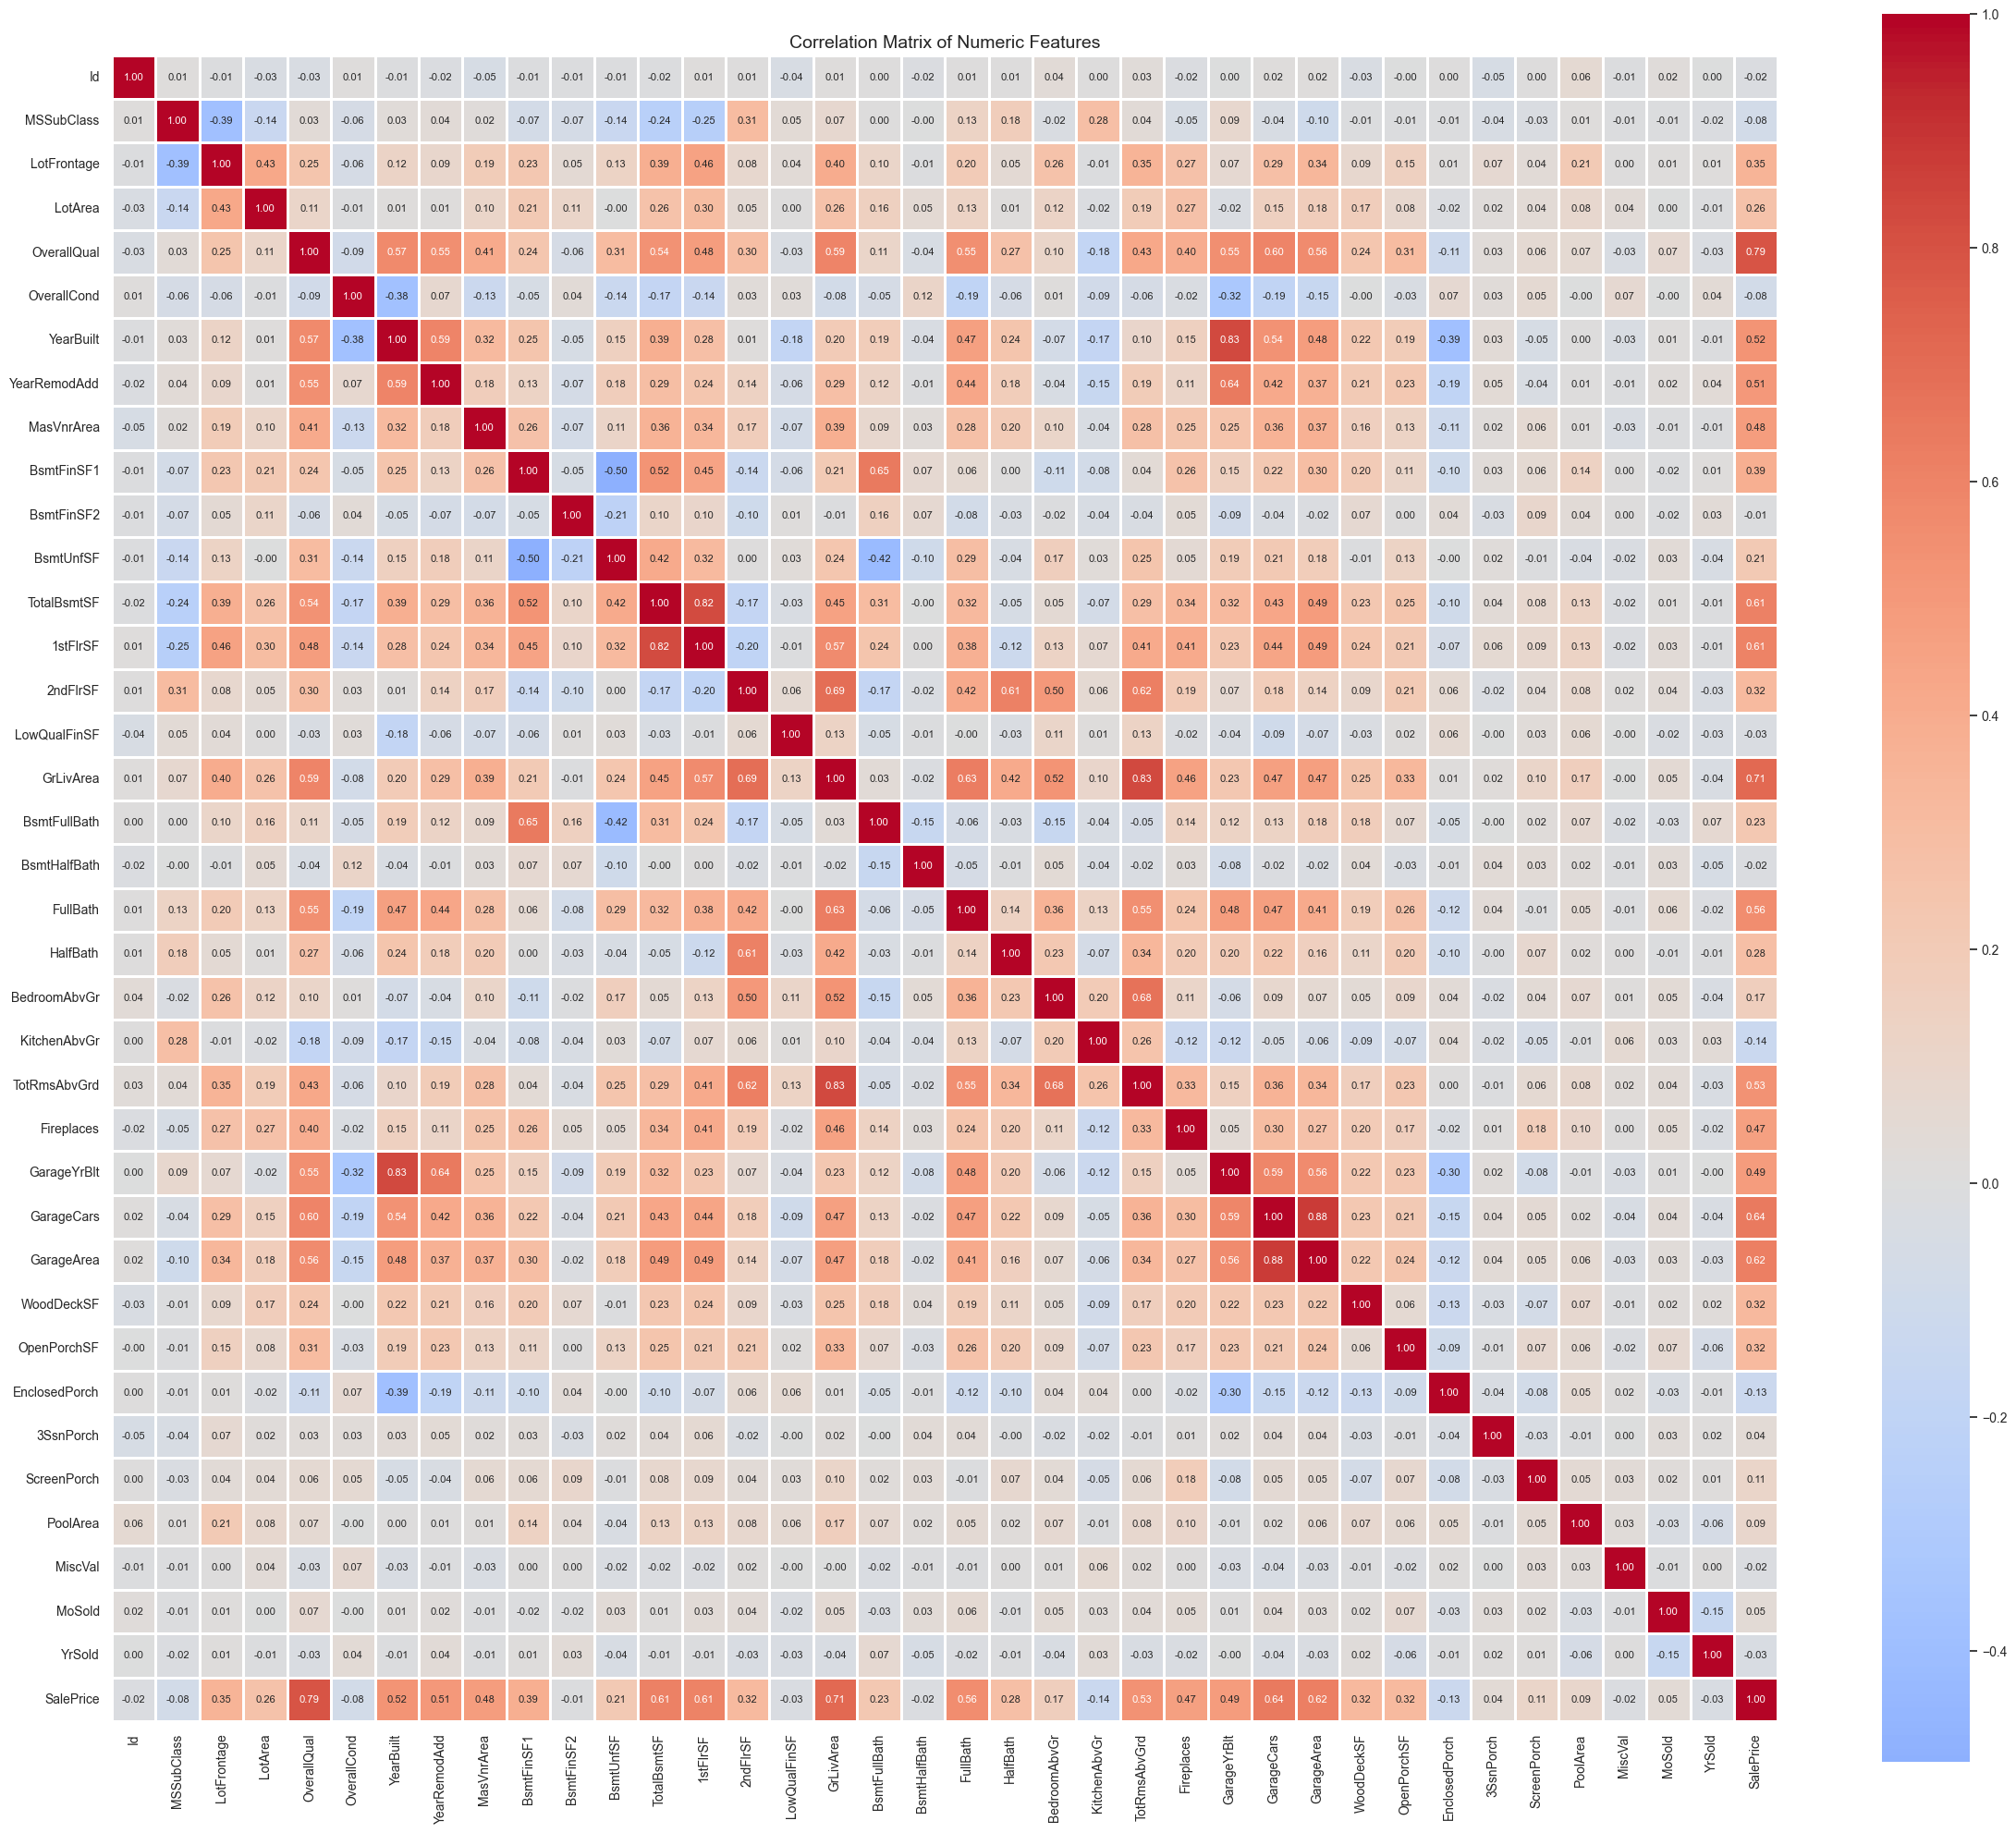

In [ ]:
housing_full = housing_raw.copy()
full_square_correlation_matrix(housing_full)

# Plots

## Basic Plots

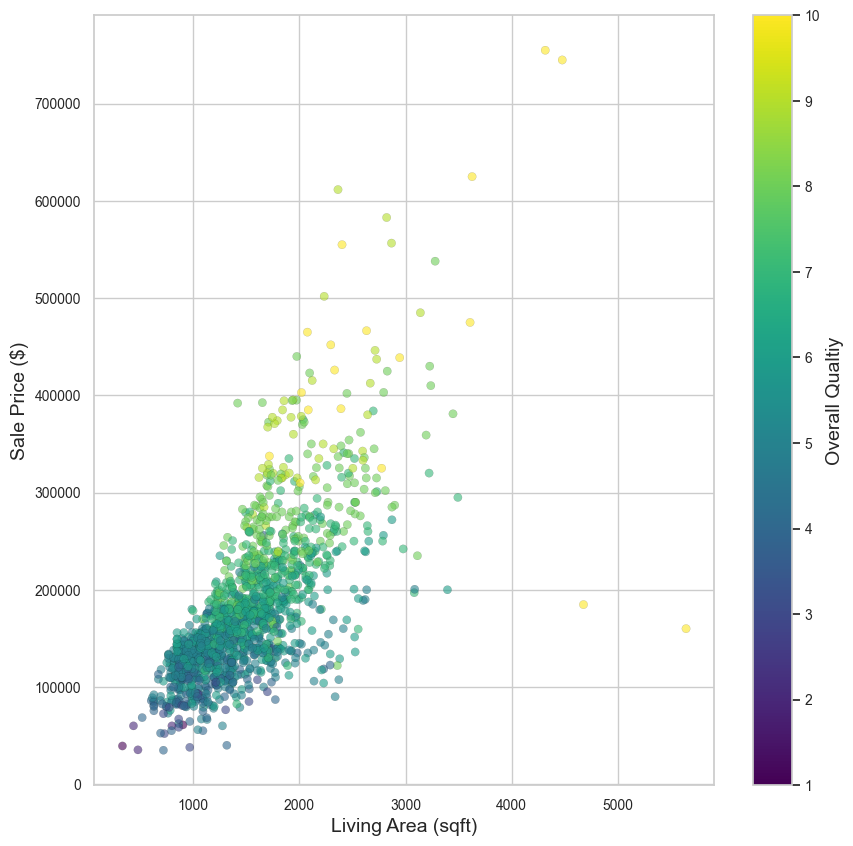

In [ ]:
scatter_plot_colormap(x=cols.GrLivArea, xlabel="Living Area (sqft)", y=cols.SalePrice, ylabel="Sale Price ($)", hue=cols.OverallQual, cbar_title="Overall Qualtiy", )

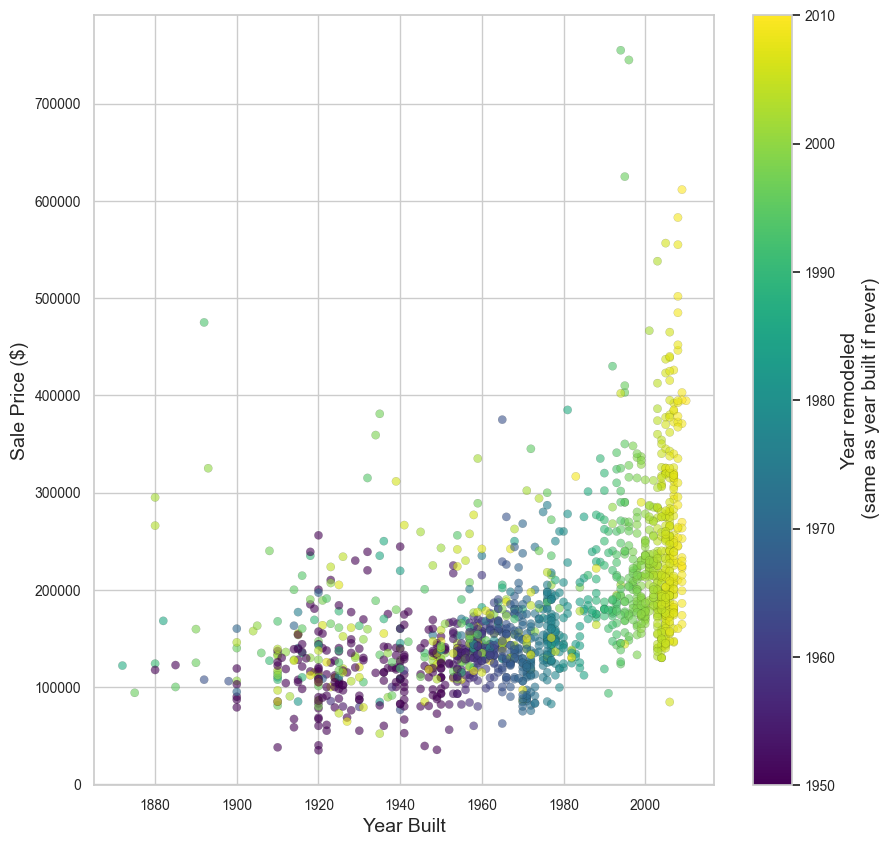

In [ ]:
scatter_plot_colormap(x=cols.YearBuilt, xlabel="Year Built", y=cols.SalePrice, ylabel="Sale Price ($)", hue=cols.YearRemodAdd, cbar_title="Year remodeled\n (same as year built if never)")

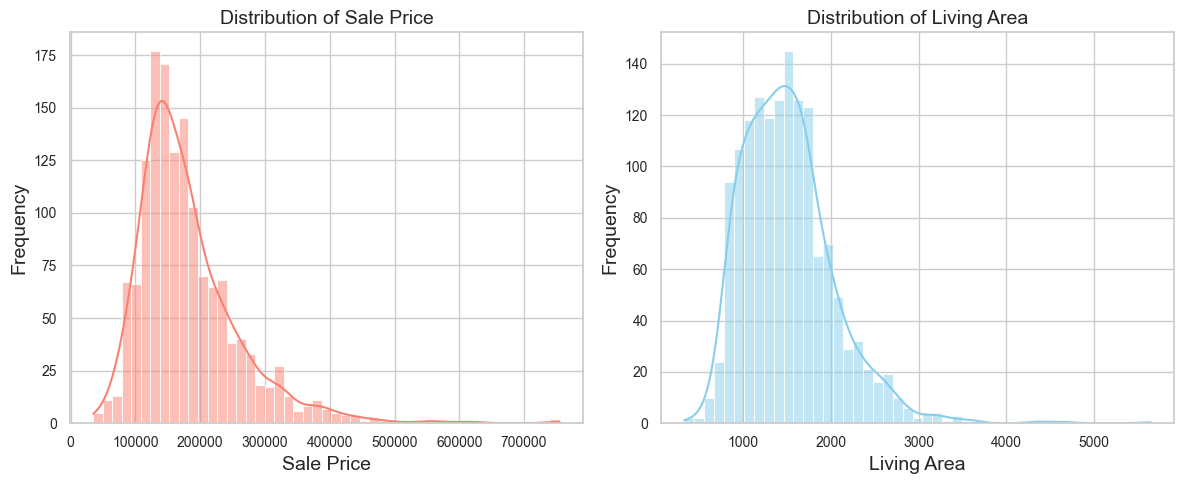

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set up subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Distribution of SalePrice
sns.histplot(data=housing_full, x='SalePrice', kde=True, ax=ax1, color='salmon')
ax1.set_xlabel('Sale Price')
ax1.set_ylabel('Frequency')
ax1.set_title('Distribution of Sale Price')

# Distribution of GrLivArea
sns.histplot(data=housing_full, x='GrLivArea', kde=True, ax=ax2, color='skyblue')
ax2.set_xlabel('Living Area')
ax2.set_ylabel('Frequency')
ax2.set_title('Distribution of Living Area')



plt.tight_layout()
plt.show()

## Matrix Plots and Correlation

<Figure size 5000x5000 with 0 Axes>

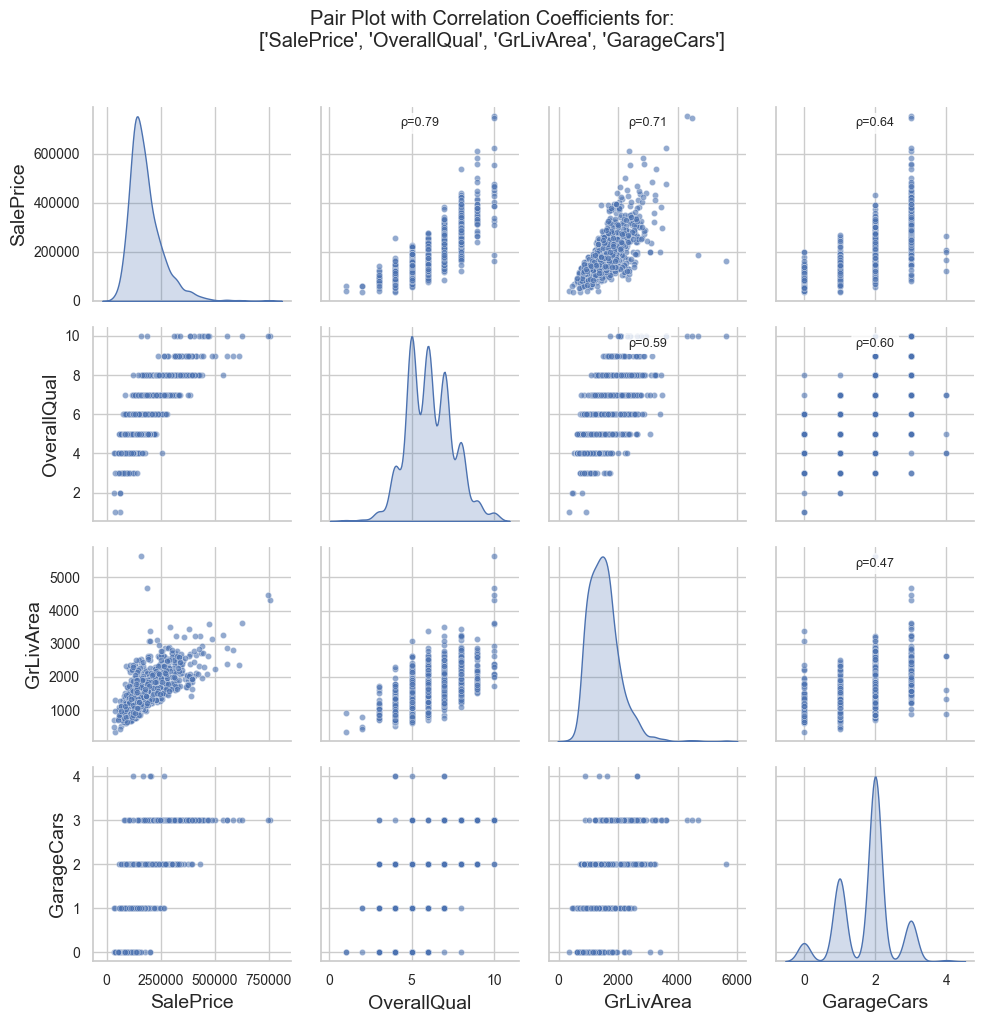

In [ ]:
square_matrix_plots(["SalePrice", "OverallQual", "GrLivArea", "GarageCars"], figsize=50)

    

<Figure size 2000x2000 with 0 Axes>

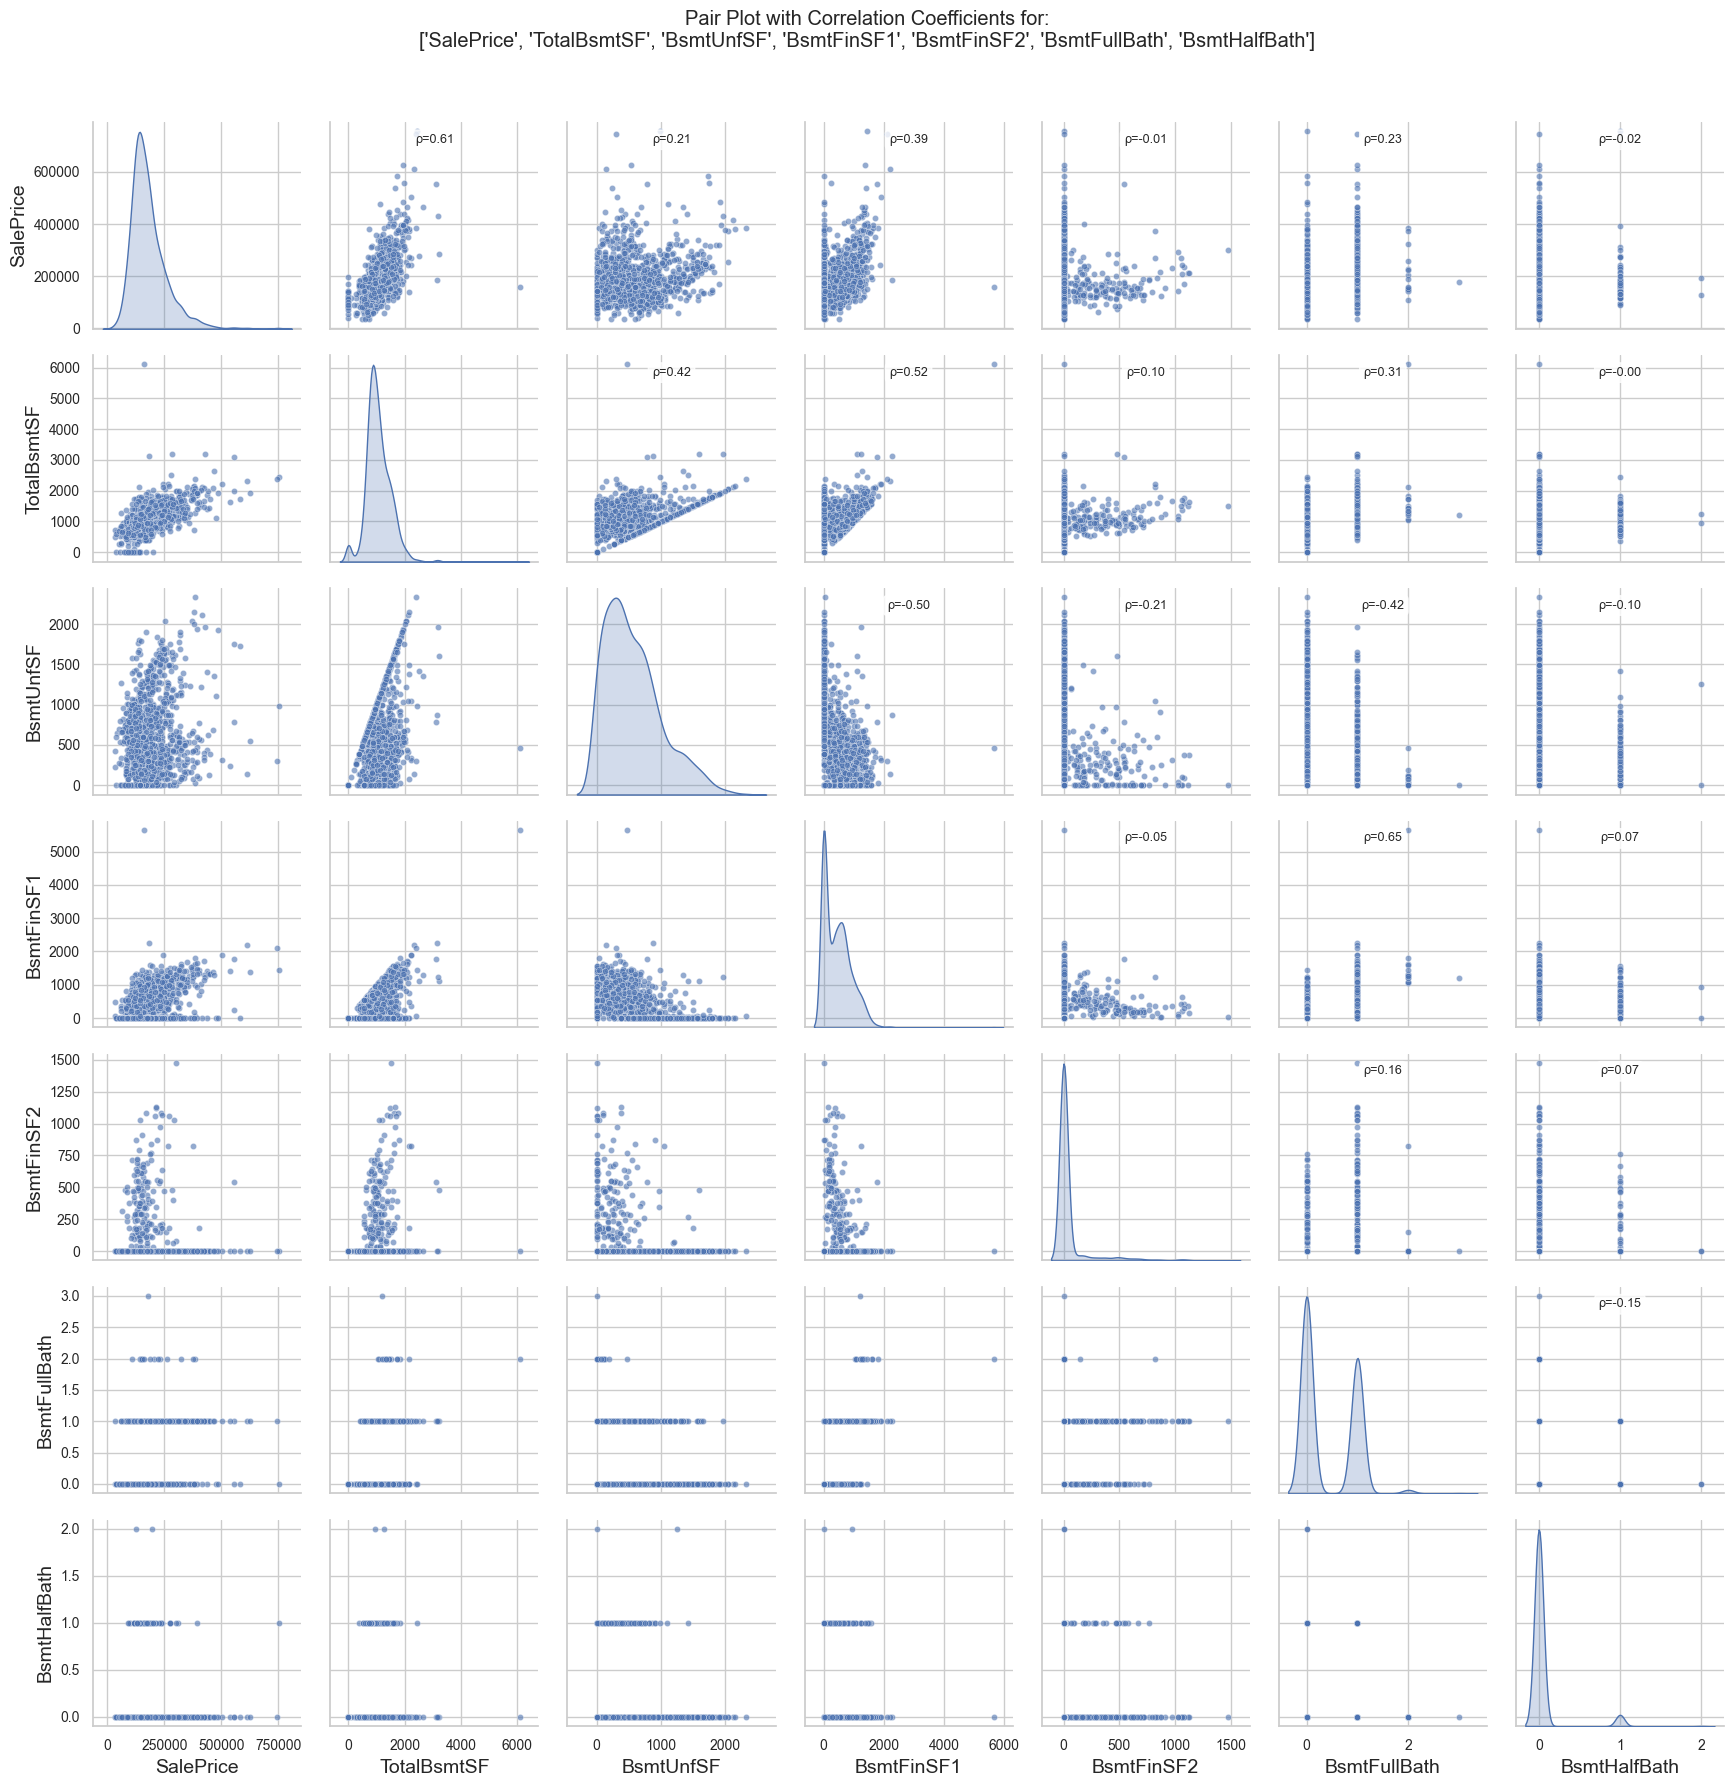

<Figure size 2000x2000 with 0 Axes>

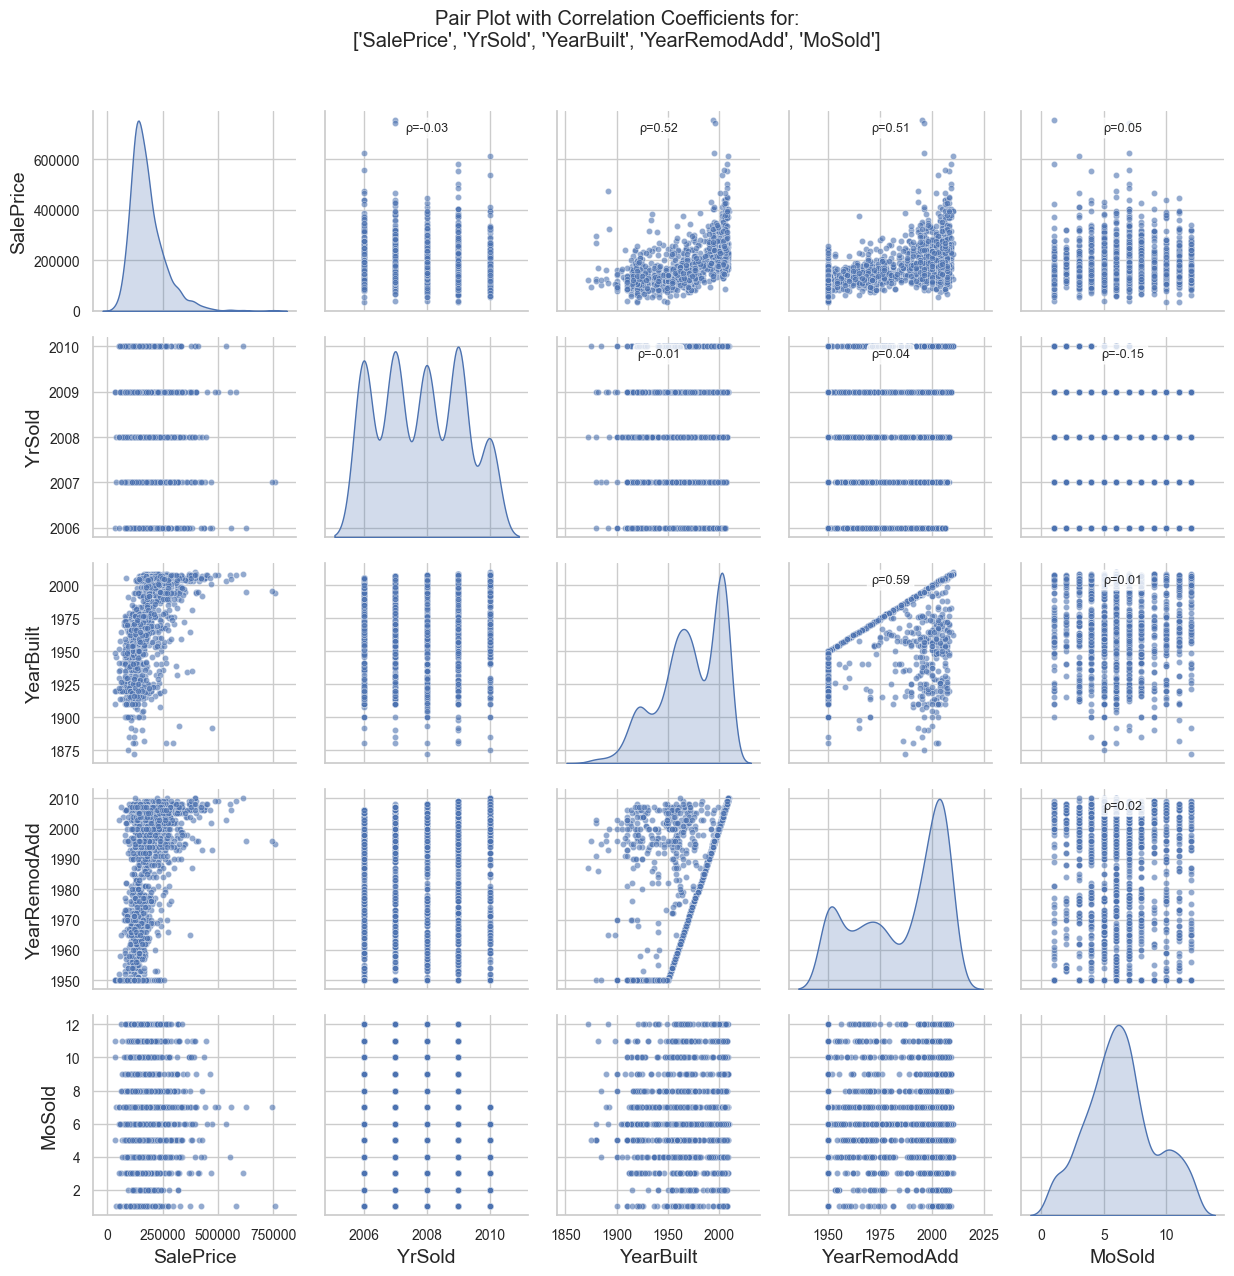

<Figure size 2000x2000 with 0 Axes>

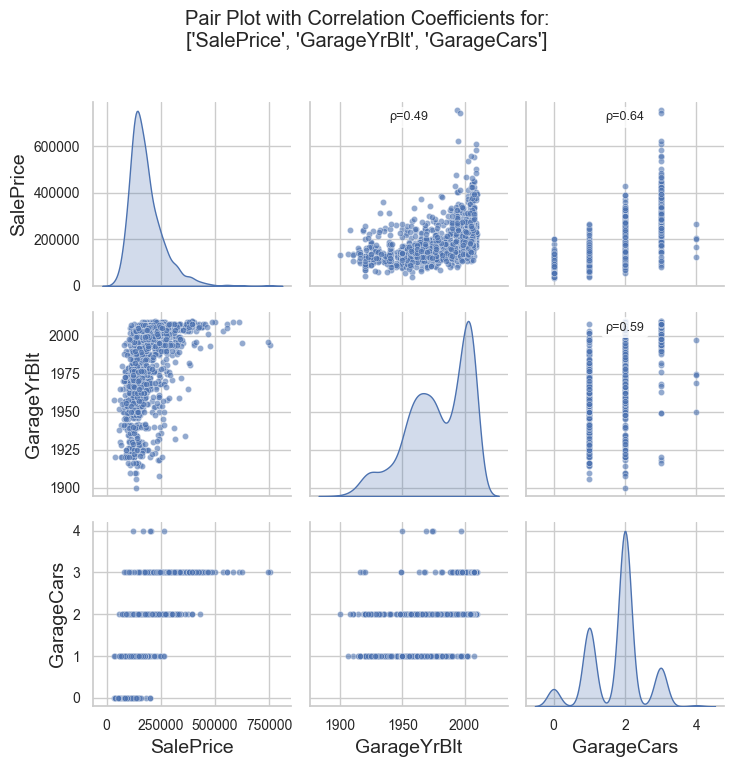

<Figure size 2000x2000 with 0 Axes>

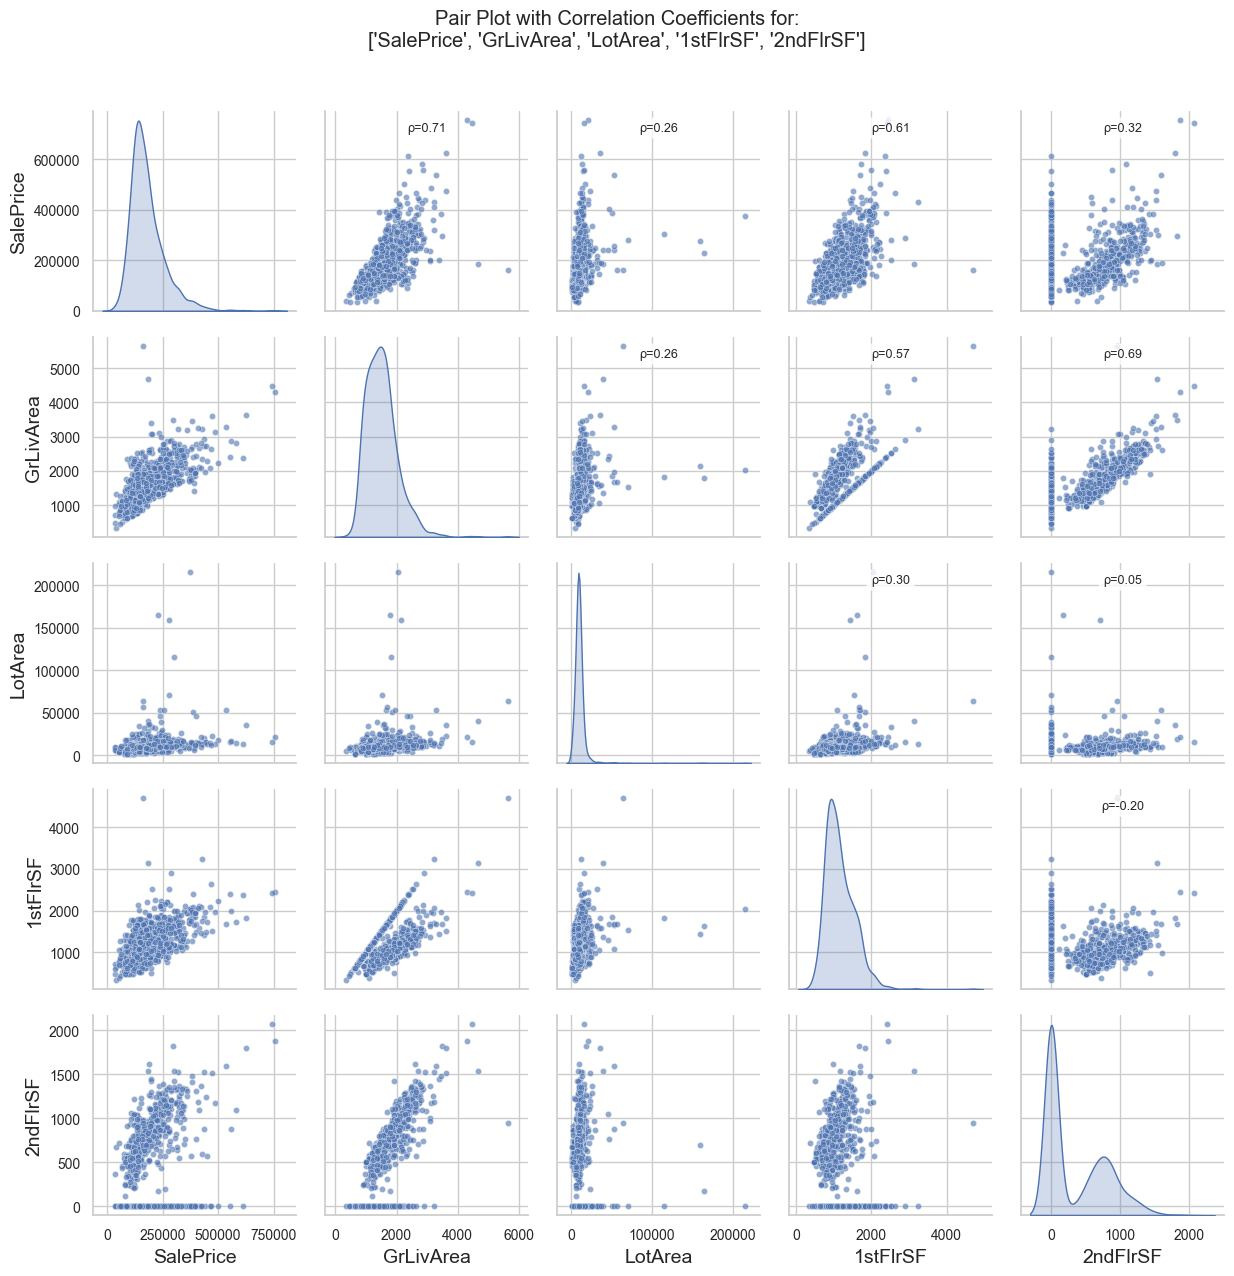

<Figure size 2000x2000 with 0 Axes>

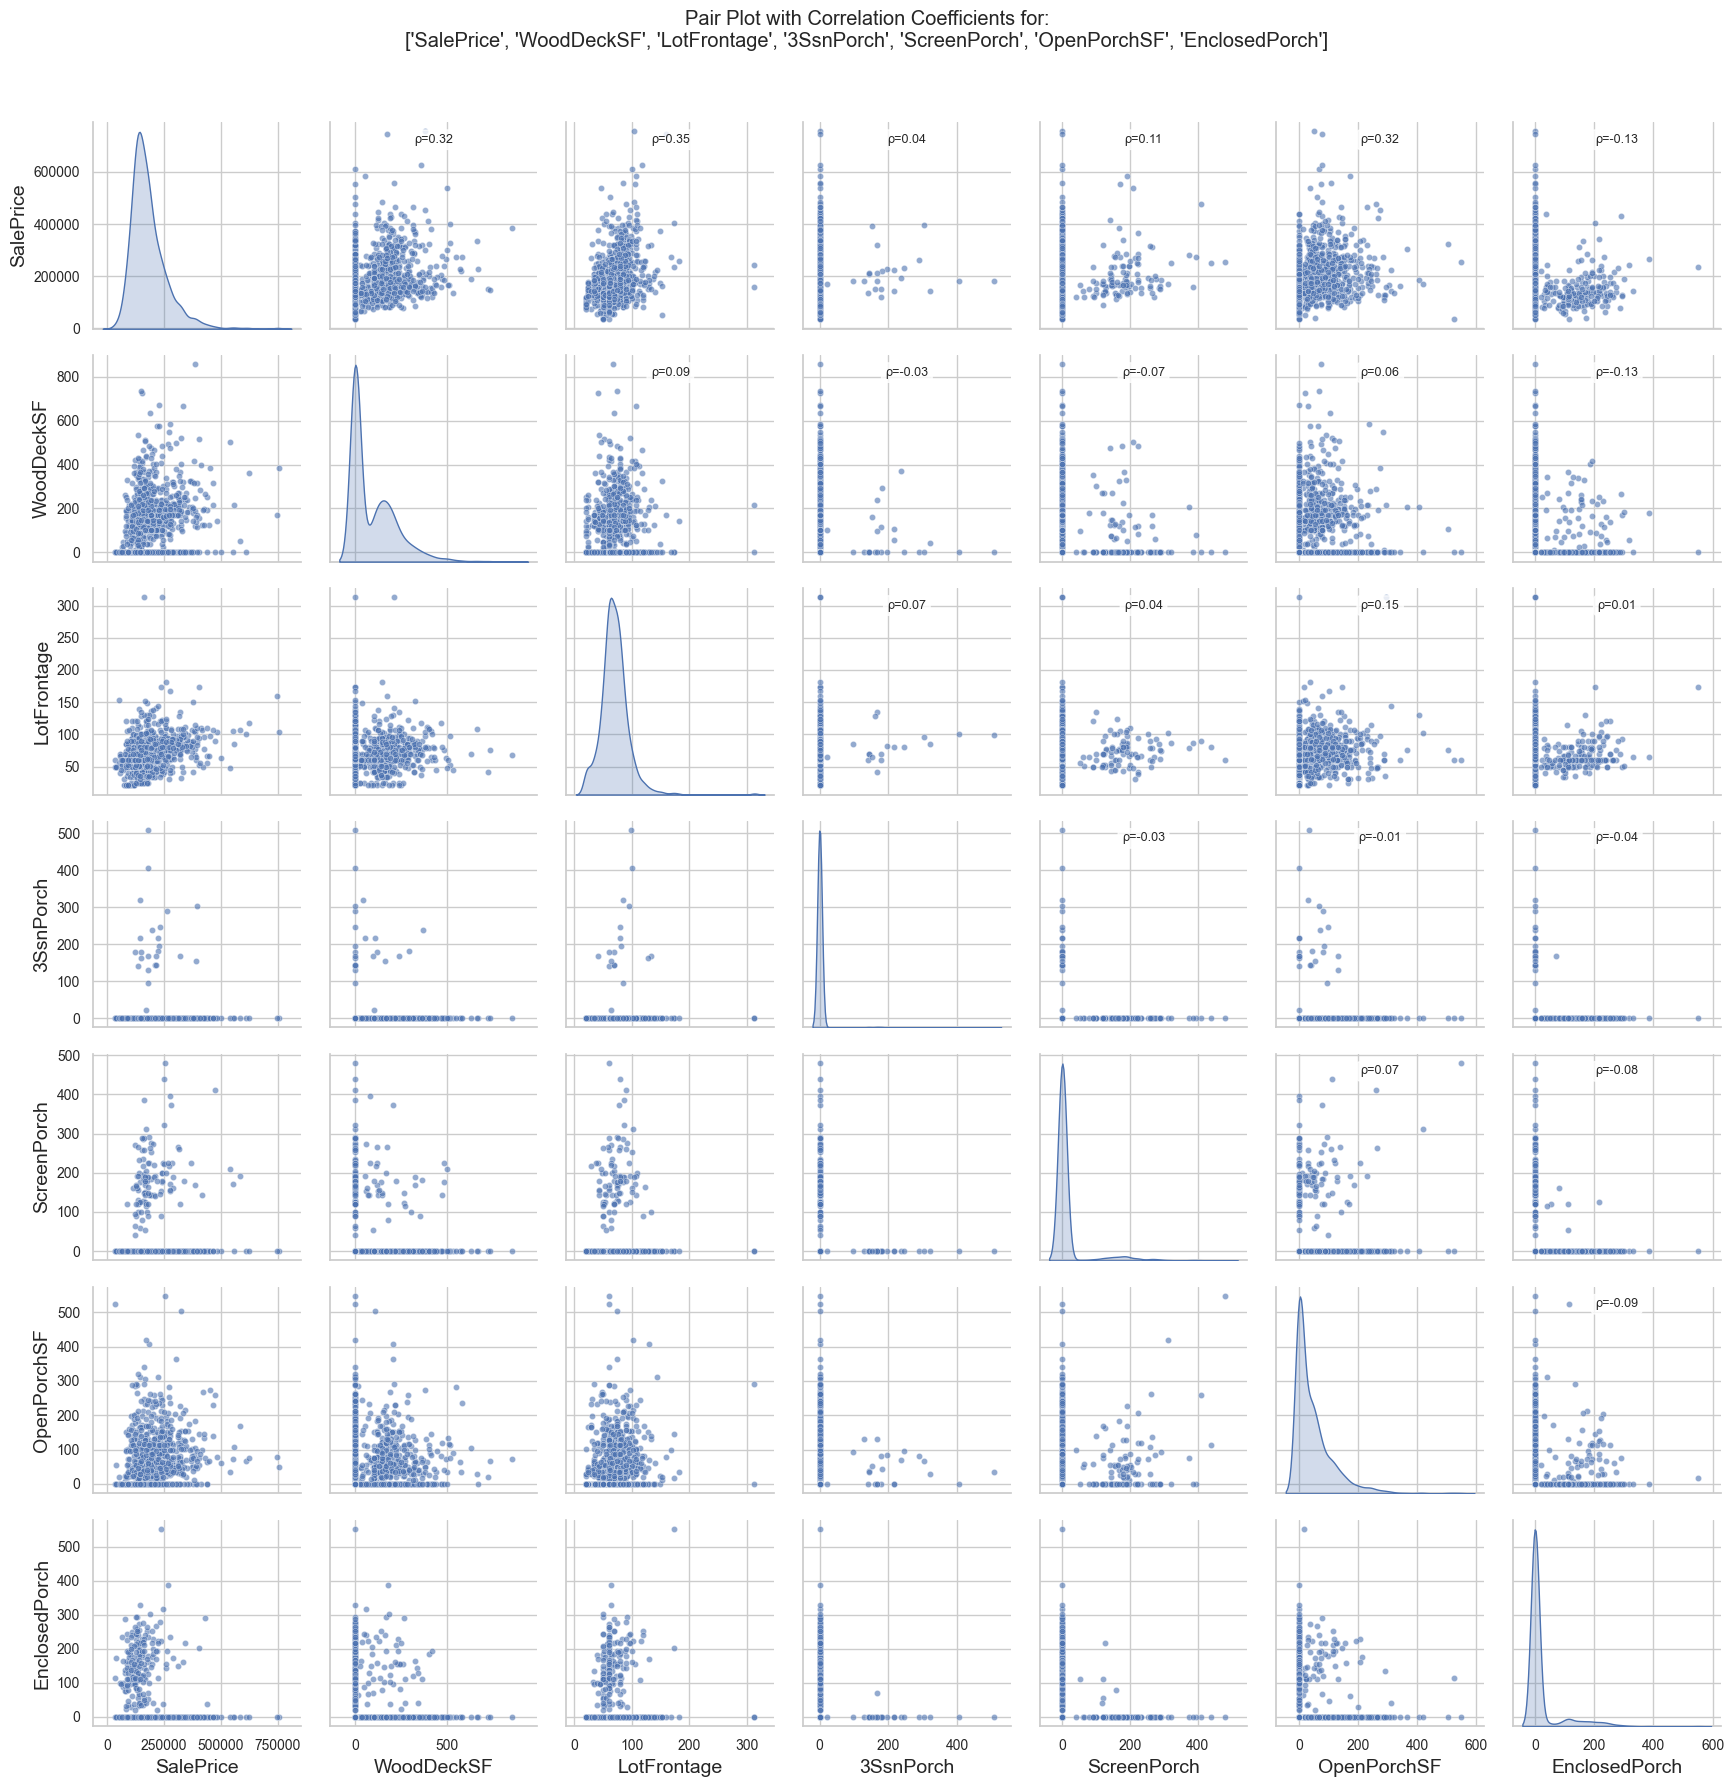

<Figure size 2000x2000 with 0 Axes>

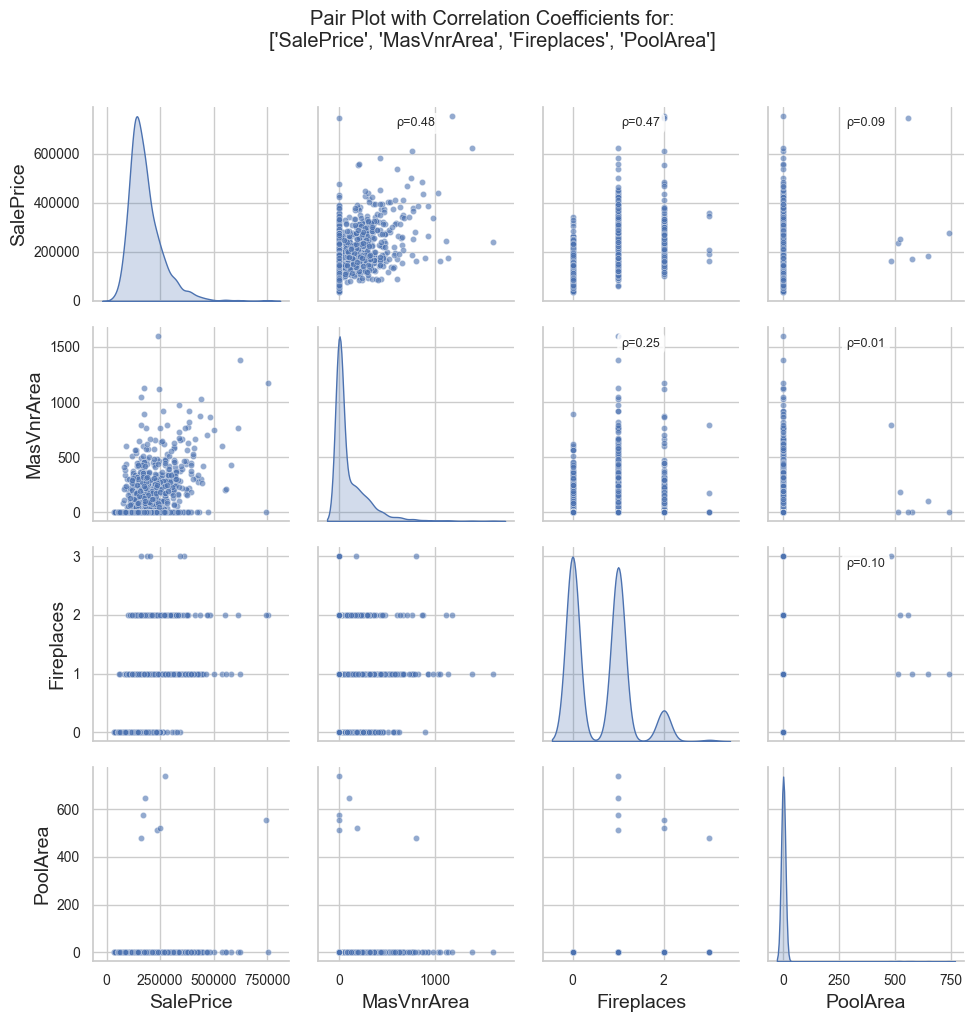

<Figure size 2000x2000 with 0 Axes>

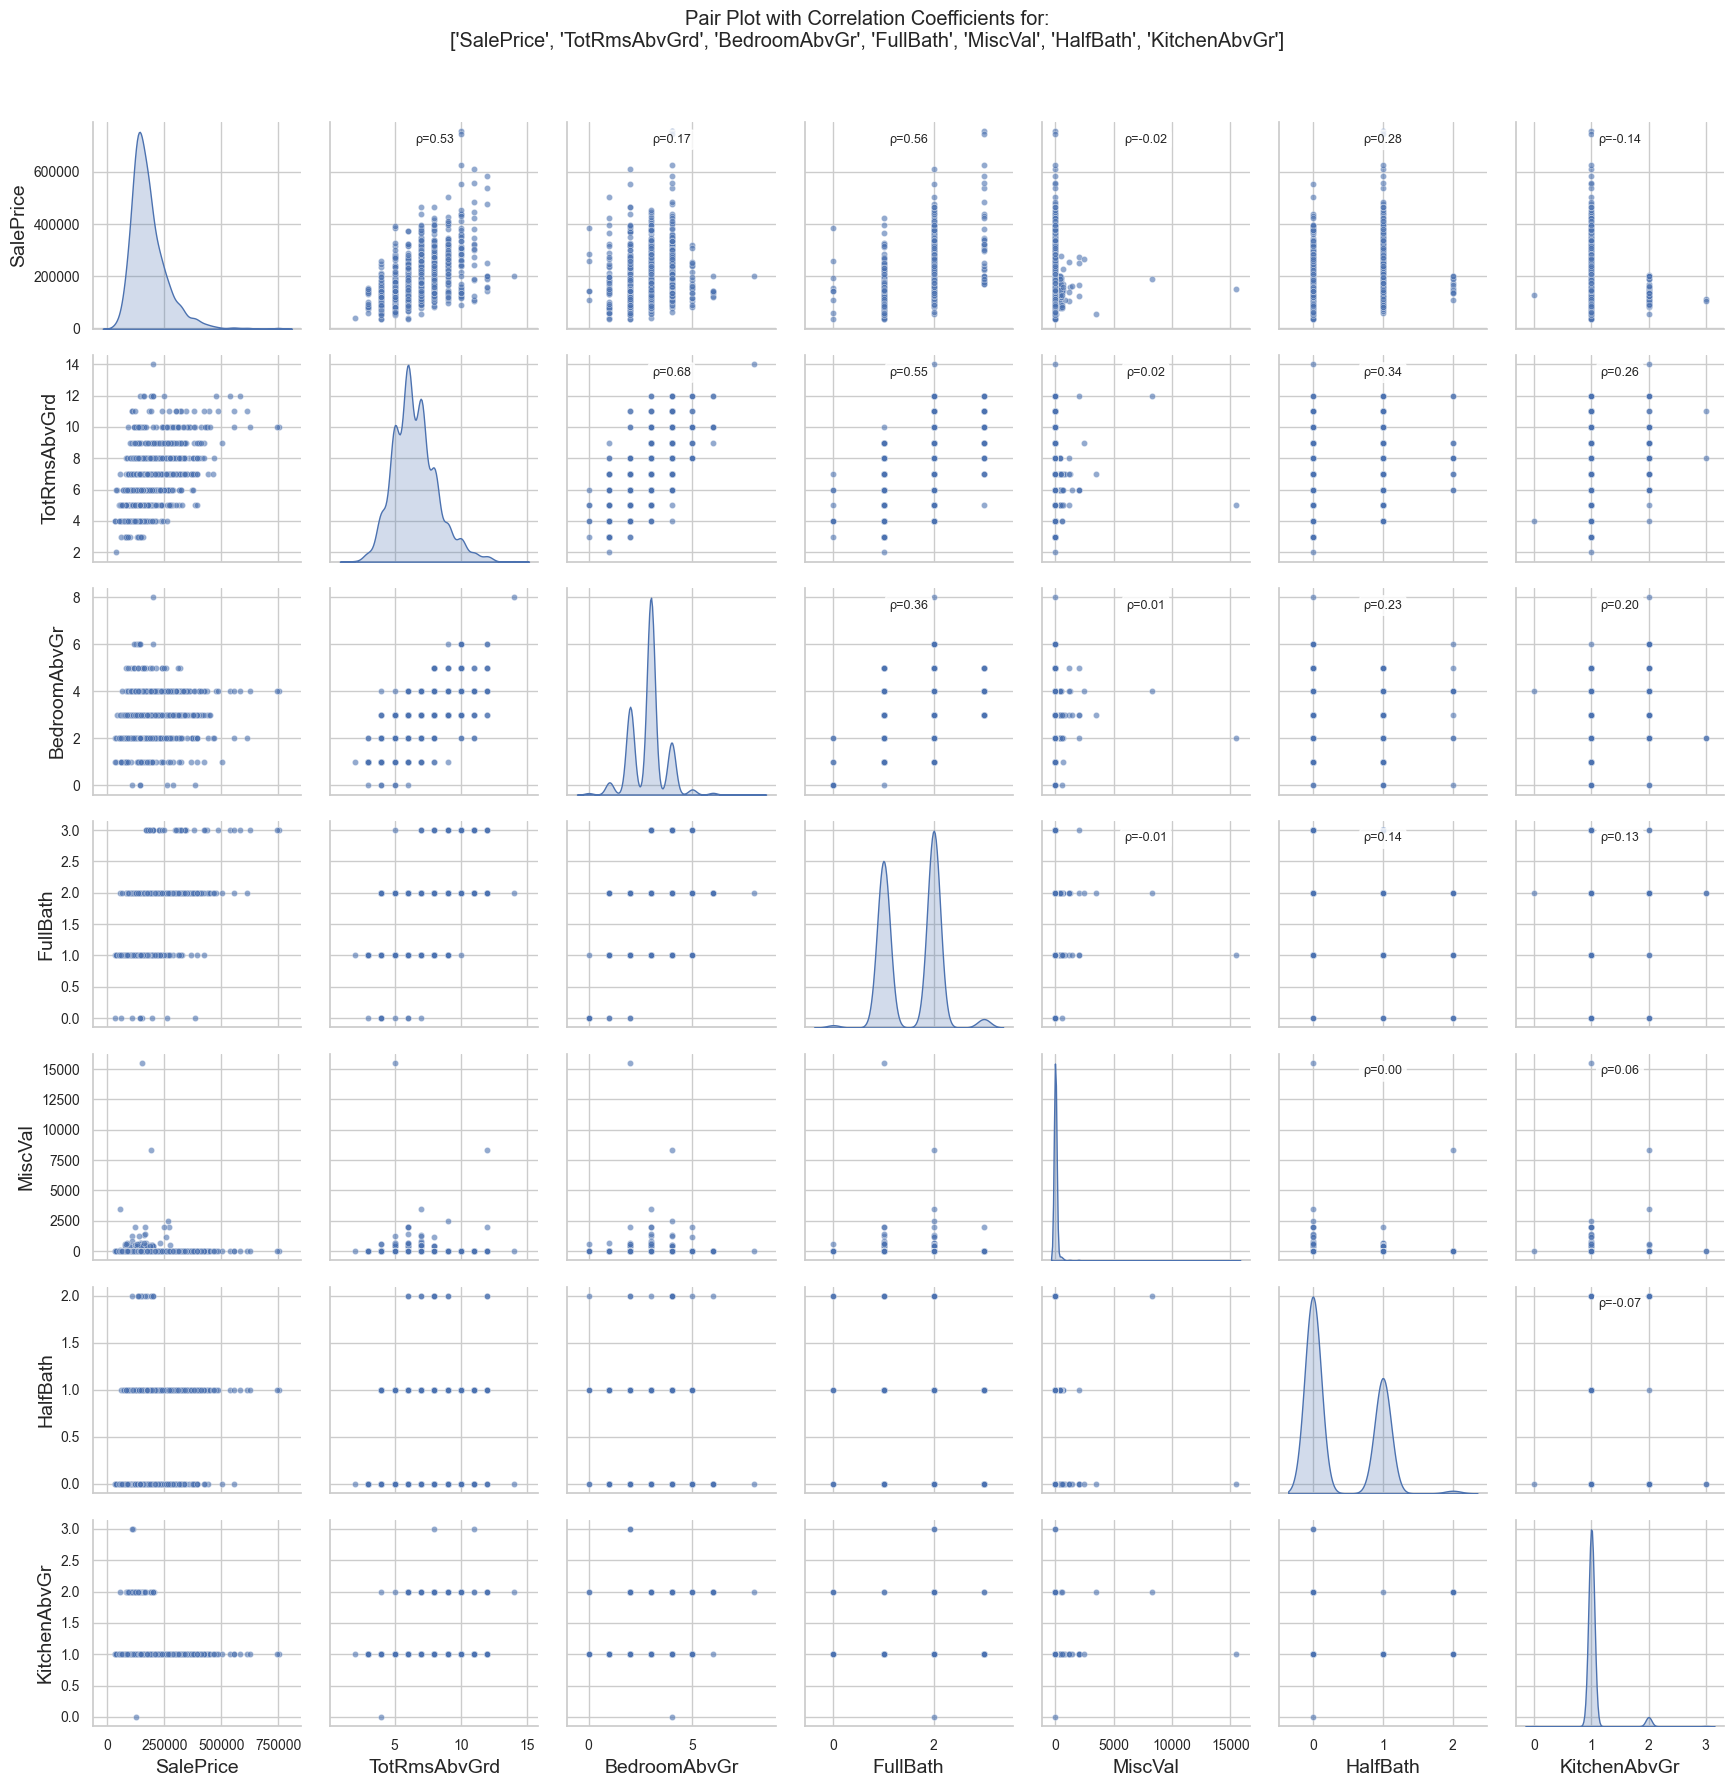

<Figure size 2000x2000 with 0 Axes>

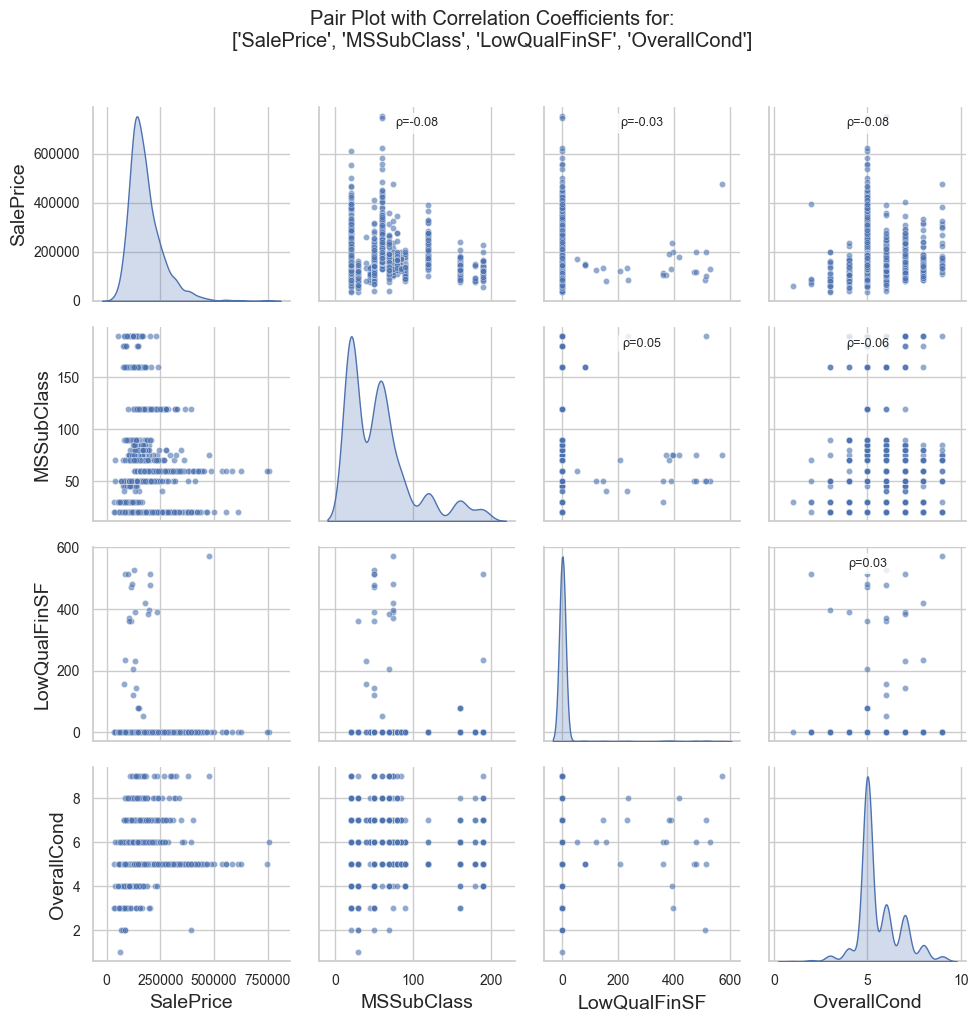

In [ ]:


# Basement
square_matrix_plots(["SalePrice", "TotalBsmtSF", "BsmtUnfSF", "BsmtFinSF1", "BsmtFinSF2", "BsmtFullBath", "BsmtHalfBath"])

# Dates
square_matrix_plots(["SalePrice", "YrSold", "YearBuilt", "YearRemodAdd", "MoSold"])

# Garage
square_matrix_plots(["SalePrice", "GarageYrBlt", "GarageCars"])

# Area
square_matrix_plots(["SalePrice", "GrLivArea" , "LotArea", "1stFlrSF", "2ndFlrSF"])

# Front
square_matrix_plots(["SalePrice", "WoodDeckSF", "LotFrontage", "3SsnPorch", "ScreenPorch", "OpenPorchSF", "EnclosedPorch"])

# Extra
square_matrix_plots(["SalePrice", "MasVnrArea", "Fireplaces", "PoolArea"])

# Rooms
square_matrix_plots(["SalePrice", "TotRmsAbvGrd", "BedroomAbvGr", "FullBath", "MiscVal", "HalfBath", "KitchenAbvGr"])


square_matrix_plots(["SalePrice", "MSSubClass", "LowQualFinSF", "OverallCond"])



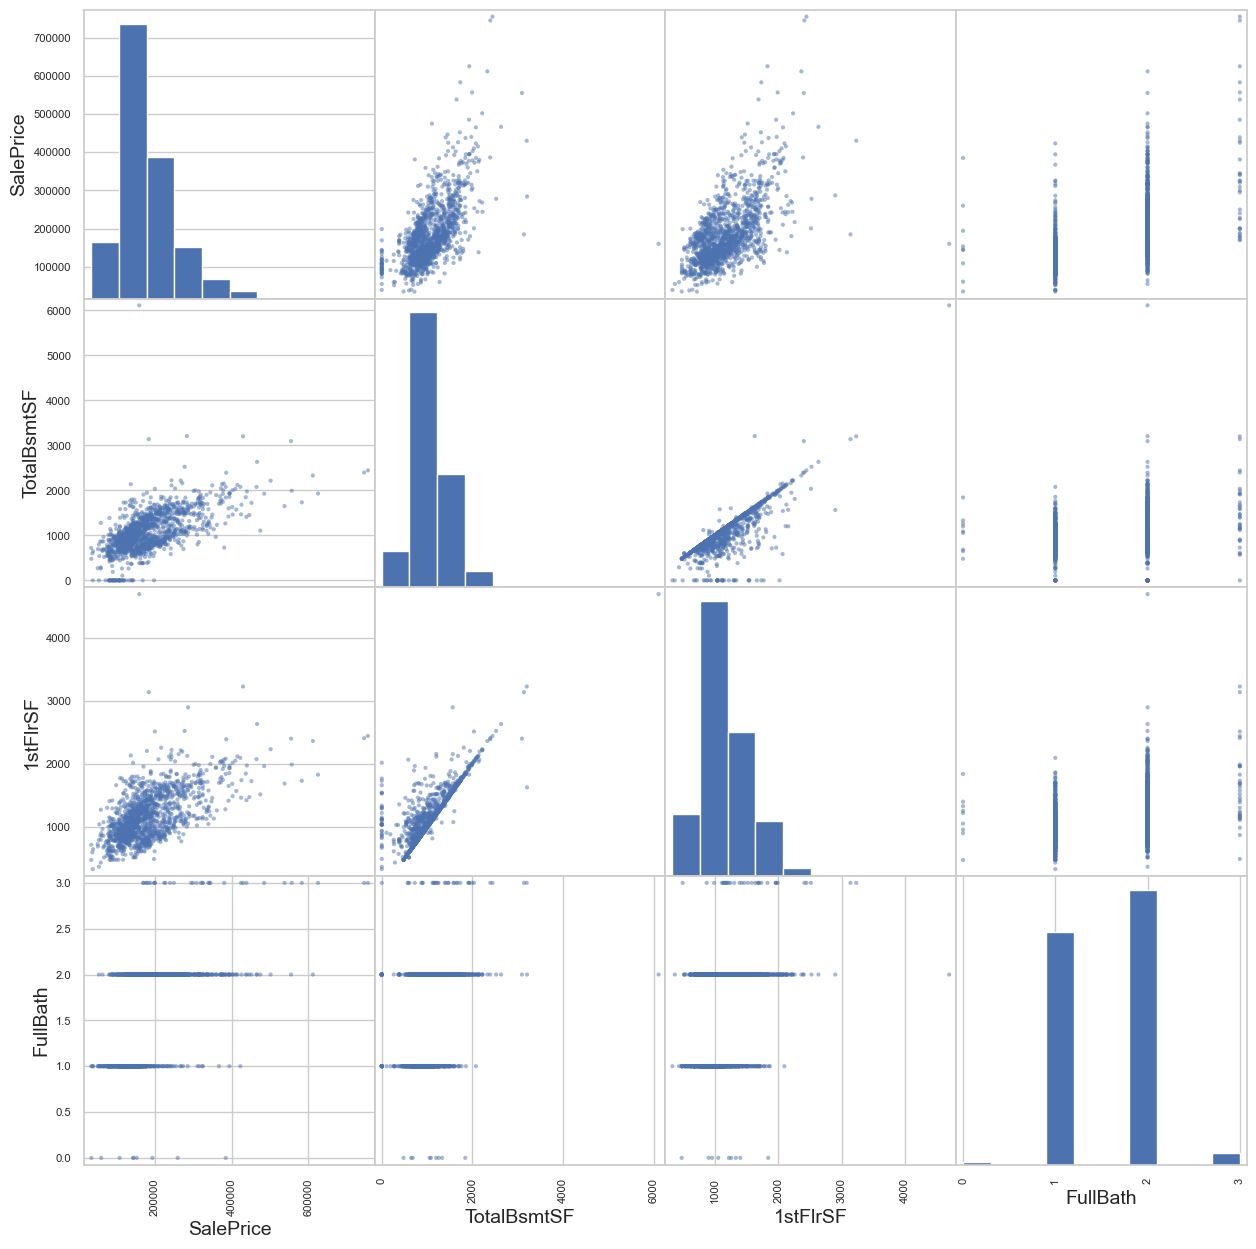

In [ ]:
attributes = ["SalePrice", "TotalBsmtSF", "1stFlrSF", "FullBath"]

scatter_matrix(housing_full[attributes], figsize=(15, 15), grid=True)

plt.show()

# Missing Values

Listing out the features that have missing values:

In [ ]:
house_info.columns_with_nan(True)

[('LotFrontage', 259),
 ('Alley', 1369),
 ('MasVnrType', 872),
 ('MasVnrArea', 8),
 ('BsmtQual', 37),
 ('BsmtCond', 37),
 ('BsmtExposure', 38),
 ('BsmtFinType1', 37),
 ('BsmtFinType2', 38),
 ('Electrical', 1),
 ('FireplaceQu', 690),
 ('GarageType', 81),
 ('GarageYrBlt', 81),
 ('GarageFinish', 81),
 ('GarageQual', 81),
 ('GarageCond', 81),
 ('PoolQC', 1453),
 ('Fence', 1179),
 ('MiscFeature', 1406)]

From the data description there are a number of features in which NA expliclty means the absence of the thing, for example 'No Pool' or 'No Garage'. 
So they can be thought of as a sort of category of their own.

In [ ]:
print("\n".join(str(x) for x in house_info.meaningful_nan_columns(True)))


('Alley', 1369)
('MasVnrType', 872)
('BsmtQual', 37)
('BsmtCond', 37)
('BsmtExposure', 38)
('BsmtFinType1', 37)
('BsmtFinType2', 38)
('FireplaceQu', 690)
('GarageType', 81)
('GarageFinish', 81)
('GarageQual', 81)
('GarageCond', 81)
('PoolQC', 1453)
('Fence', 1179)
('MiscFeature', 1406)


Here are the columns which contain null values and in which null values are not used to represent a category of their own, i.e., the absence of the thing (no pool or no fireplace), at least according to `data_description.txt`.

In [ ]:
print(house_info.problematic_columns())
print("\n\tNon-Numerical: ", house_info.problematic_non_num_columns(True))
print("\tNumerical: ", house_info.problematic_num_columns(True))

['LotFrontage', 'MasVnrArea', 'Electrical', 'GarageYrBlt']

	Non-Numerical:  [('Electrical', 1)]
	Numerical:  [('MasVnrArea', 8), ('LotFrontage', 259), ('GarageYrBlt', 81)]


Now we can filter the rows to try and find inconsistencies in the null values. 
For example pool area being greater than 0 even though pool quality is None (meaning no pool).
The function as I've defined is rather generic, one of the ways it flags inconsistencies is by checking if the value of a feature like the surface area is 0 when the corresponding quality or condition feature is set to NaN (`MasVnrType=Stone` and `MasVnrType=0`)

In [ ]:
inconsistencies = inconsistent_rows(return_results=True, verbose=True)
print("\n", inconsistencies)

Checking for logical inconsistencies...

MasVnrType → MasVnrArea: 5 inconsistencies
--------------------------------------------------------------------------------
        Id  SalePrice MasVnrType  MasVnrArea
624    625     165150        NaN       288.0
773    774     114500        NaN         1.0
1230  1231     190000        NaN         1.0
1300  1301     225000        NaN       344.0
1334  1335     125000        NaN       312.0

MasVnrType present but MasVnrArea < 10: 2 cases
--------------------------------------------------------------------------------
        Id  SalePrice MasVnrType  MasVnrArea
688    689     392000    BrkFace         0.0
1241  1242     248328      Stone         0.0

BsmtFinType1 present but BsmtFinSF1 < 10: 1 cases
--------------------------------------------------------------------------------
      Id  SalePrice BsmtFinType1  BsmtFinSF1
567  568     214000          GLQ           2

BsmtFinType2 → BsmtFinSF2: 1 inconsistencies
--------------------------------

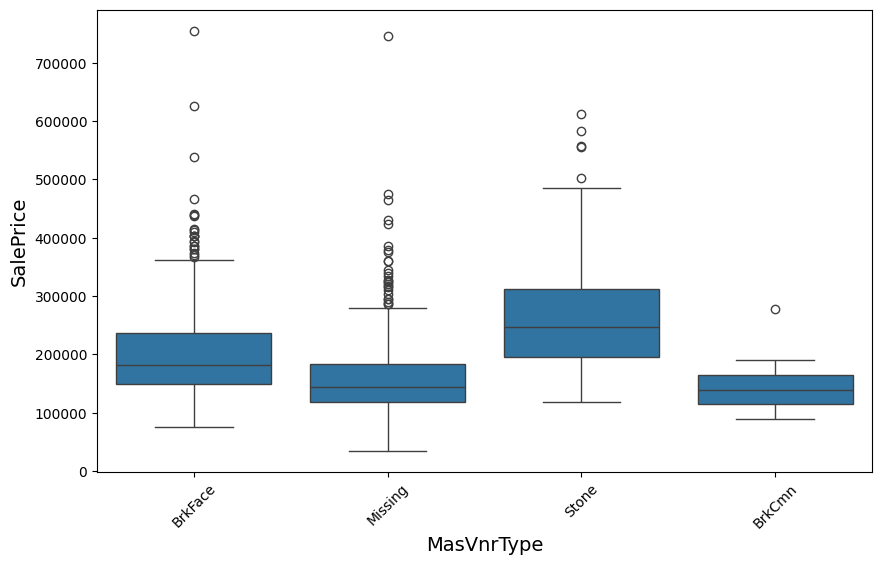

In [ ]:
box_plot(cols.MasVnrType)

# Preparing the Data

In [ ]:
housing_full = housing_raw.copy()

housing_full = prepare_data(df=housing_full, target_col=cols.SalePrice, 
                            corr_threshold=0.0, 
                            outliers_threshold=4.0, 
                            remove_inconsistent_rows=False,                 
                            verbose=True)


Removing outliers:
SalePrice bounds: -206125.0 - 550100.0
Removed 7 outliers out of 1460 datapoints in 'SalePrice'


Numerical features: 37
Categorical features: 43


Separating the target from the features then making a train set and a test set.

In [ ]:
X = housing_full.drop(cols.SalePrice, axis=1)
X = X.drop(cols.Id, axis=1)
y = housing_full[cols.SalePrice]



Splitting the training and the test set

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.05, random_state=42
)

Assembling the pipelines

In [ ]:
feature_selection_preprocessor = create_preprocessor(X, use_feature_selection=True, max_features=80)
feature_selection_preprocessor

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('feature_engineer', ...), ('transformer', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,feature_names,"['MSSubClass', 'MSZoning', ...]"
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('log_num', ...), ('num', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_th

In [ ]:
all_features_preprocessor = create_preprocessor(X)
all_features_preprocessor

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('feature_engineer', ...), ('transformer', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,feature_names,"['MSSubClass', 'MSZoning', ...]"
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('log_num', ...), ('num', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_thresho

# Training the models

For some of these models I train a version which is trained to predict the log of the target and another which directly predicts the target.

Every time a model is trained I store useful information like the test RMSE or the generalization error in `results`, which is a list of dictionaries, one dict for each algorithm.
I also select the best model and store it in a variable.

I use `results` to compare between the algorithms, plot that info and select the best one, then I use the best 3 models to make ensemble predictions.

In [ ]:
results = []

### Randomforest and Gridsearch

In [ ]:
random_forest_preprocessor = create_preprocessor(
    X,
    target_col=cols.SalePrice,
    use_feature_selection=False,
    # max_features=80,
    use_log_features=False
)

random_forest_pipeline = Pipeline([
    ('preprocessor', random_forest_preprocessor),
    ("selector", FeatureSelector()),
    ('model', RandomForestRegressor(random_state=42))
])

random_forest_pipeline_with_log = TransformedTargetRegressor(
    regressor=random_forest_pipeline,
    func=np.log1p,      
    inverse_func=np.expm1  
)

random_forest_param_grid = {
    "regressor__selector__max_features": [60, 80, 100],
    'regressor__model__n_estimators': [75, 100, 150],
    'regressor__model__max_depth': [10, 15, 20, 40, None],
    'regressor__model__min_samples_split': [2, 5]
}
    
random_forest_grid_search = GridSearchCV(
    random_forest_pipeline_with_log,
    random_forest_param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

Training the model

In [ ]:
random_forest_fitted_model, random_forest_res = train_and_evaluate(
    random_forest_grid_search, 
    X_train, X_test, y_train, y_test,
    technique_name="RandomForest\n(log(target))"
)

results.append(random_forest_res)

Fitting 5 folds for each of 90 candidates, totalling 450 fits

Training RandomForest
(log(target))

RANDOMFOREST
(LOG(TARGET)) RESULTS
Cross-validation:
  CV type:     GridSearchCV
  Scoring:     neg_mean_squared_error
  Best score:  -693189627.9523
  Best params: {'regressor__model__max_depth': 15, 'regressor__model__min_samples_split': 2, 'regressor__model__n_estimators': 100, 'regressor__selector__max_features': 80}

Performance:
  Train RMSE: 9,935.32
  Test RMSE:  20,479.42
  Gap:        10,544.10

Baseline:
  Avg target (test): 169,247.97
  RMSE % of avg:     12.10%
Estimator:
  Class: TransformedTargetRegressor
  Non-default hyperparameters:
    func: <ufunc 'log1p'>
    inverse_func: <ufunc 'expm1'>
    regressor: Pipeline(steps=[('preprocessor',
                 Pipeline(steps=[('feature_engineer',
                                  FeatureEngineer(feature_names=['MSSubClass',
                                                                 'MSZoning',
                         

In [ ]:
best_random_forest = random_forest_fitted_model.best_estimator_

In [ ]:
random_forest_cv_res = pd.DataFrame(random_forest_grid_search.cv_results_)
random_forest_cv_res.sort_values(by="mean_test_score", ascending=False, inplace=True)
random_forest_cv_res.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_regressor__model__max_depth,param_regressor__model__min_samples_split,param_regressor__model__n_estimators,param_regressor__selector__max_features,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
22,7.444613,0.238904,1.080971,0.541639,15,2,100,80,"{'regressor__model__max_depth': 15, 'regressor...",-5.627426e+08,-9.060800e+08,-6.364149e+08,-6.955444e+08,-6.651663e+08,-6.931896e+08,1.151981e+08,1
19,6.335762,0.478934,0.976359,0.530451,15,2,75,80,"{'regressor__model__max_depth': 15, 'regressor...",-5.831393e+08,-9.104580e+08,-6.309832e+08,-6.949699e+08,-6.514849e+08,-6.942071e+08,1.139505e+08,2
37,6.161116,0.496572,1.605463,0.680743,20,2,75,80,"{'regressor__model__max_depth': 20, 'regressor...",-5.781460e+08,-9.216847e+08,-6.305197e+08,-6.962286e+08,-6.496291e+08,-6.952416e+08,1.193803e+08,3
40,7.551694,0.587018,1.069301,0.517443,20,2,100,80,"{'regressor__model__max_depth': 20, 'regressor...",-5.622648e+08,-9.156571e+08,-6.299229e+08,-7.073292e+08,-6.629118e+08,-6.956172e+08,1.197689e+08,4
58,7.368264,0.115205,0.411853,0.248509,40,2,100,80,"{'regressor__model__max_depth': 40, 'regressor...",-5.609337e+08,-9.127354e+08,-6.327900e+08,-7.073549e+08,-6.703425e+08,-6.968313e+08,1.183186e+08,5


### XGBoost

In [ ]:
from xgboost import XGBRegressor
from scipy.stats import randint

xgboost_preprocessor = create_preprocessor(
    X, 
    target_col=cols.SalePrice,
    use_feature_selection=False,
    use_log_features=True
)

xgboost_pipeline = Pipeline([
    ('preprocessor', xgboost_preprocessor),
    ("selector", FeatureSelector()),
    ('model', XGBRegressor(random_state=42, tree_method='hist'))
])

xgboost_pipeline_with_log = TransformedTargetRegressor(
    regressor=xgboost_pipeline,
    func=np.log1p,
    inverse_func=np.expm1
)

reg_xgboost_param_dist = {
    "regressor__selector__max_features": randint(50, 120),
    'regressor__model__n_estimators': randint(300, 801),         
    'regressor__model__max_depth': randint(3, 7),                
    'regressor__model__learning_rate': uniform(0.03, 0.12),      
    'regressor__model__subsample': uniform(0.6, 0.4),            
    'regressor__model__colsample_bytree': uniform(0.6, 0.4),     
    'regressor__model__min_child_weight': randint(1, 11),        
    'regressor__model__gamma': uniform(0.0, 5.0),                
}

xgboost_param_dist = {
    "selector__max_features": randint(50, 120),
    'model__n_estimators': randint(300, 801),         
    'model__max_depth': randint(3, 7),                
    'model__learning_rate': uniform(0.03, 0.12),      
    'model__subsample': uniform(0.6, 0.4),            
    'model__colsample_bytree': uniform(0.6, 0.4),     
    'model__min_child_weight': randint(1, 11),        
    'model__gamma': uniform(0.0, 5.0),                
}

xgboost_random_search = RandomizedSearchCV(
    estimator=xgboost_pipeline,
    param_distributions=xgboost_param_dist,
    n_iter=40,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    random_state=42,
    verbose=1
)


xgboost_log_random = RandomizedSearchCV(
    estimator=xgboost_pipeline_with_log,
    param_distributions=reg_xgboost_param_dist,
    n_iter=40,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    random_state=42,
    verbose=1
)


In [ ]:
xgboost_fitted_model, xgboost_res = train_and_evaluate(
    xgboost_random_search, 
    X_train, X_test, y_train, y_test,
    technique_name="XGBoost"
)

xgboostlog_fitted_model, xgboostlog_res = train_and_evaluate(
    xgboost_log_random, 
    X_train, X_test, y_train, y_test,
    technique_name="XGBoost\n(log(target))"
)

results.append(xgboost_res)
results.append(xgboostlog_res)

Fitting 3 folds for each of 40 candidates, totalling 120 fits

Training XGBoost

XGBOOST RESULTS
Cross-validation:
  CV type:     RandomizedSearchCV
  Scoring:     neg_mean_squared_error
  Best score:  -558112810.6667
  Best params: {'model__colsample_bytree': np.float64(0.9624395150874216), 'model__gamma': np.float64(2.1719718275521434), 'model__learning_rate': np.float64(0.07200940892336108), 'model__max_depth': 3, 'model__min_child_weight': 1, 'model__n_estimators': 752, 'model__subsample': np.float64(0.6920741072966221), 'selector__max_features': 97}

Performance:
  Train RMSE: 6,092.48
  Test RMSE:  16,983.74
  Gap:        10,891.26

Baseline:
  Avg target (test): 169,247.97
  RMSE % of avg:     10.03%
Estimator:
  Class: XGBRegressor
  All hyperparameters at default values
Fitting 3 folds for each of 40 candidates, totalling 120 fits

Training XGBoost
(log(target))

XGBOOST
(LOG(TARGET)) RESULTS
Cross-validation:
  CV type:     RandomizedSearchCV
  Scoring:     neg_mean_squared_e

In [ ]:
categorical_cols = house_info.non_num_columns()
for col in categorical_cols:
    print(col, X[col].nunique())


MSZoning 5
Street 2
Alley 2
LotShape 4
LandContour 4
Utilities 2
LotConfig 5
LandSlope 3
Neighborhood 25
Condition1 9
Condition2 8
BldgType 5
HouseStyle 8
RoofStyle 6
RoofMatl 8
Exterior1st 15
Exterior2nd 16
MasVnrType 3
ExterQual 4
ExterCond 5
Foundation 6
BsmtQual 4
BsmtCond 4
BsmtExposure 4
BsmtFinType1 6
BsmtFinType2 6
Heating 6
HeatingQC 5
CentralAir 2
Electrical 5
KitchenQual 4
Functional 7
FireplaceQu 5
GarageType 6
GarageFinish 3
GarageQual 5
GarageCond 5
PavedDrive 3
PoolQC 3
Fence 4
MiscFeature 4
SaleType 9
SaleCondition 6


In [ ]:
best_xgboost = xgboost_fitted_model.best_estimator_
best_xgboostlog = xgboostlog_fitted_model.best_estimator_


In [ ]:
# xgboost__cv_res = pd.DataFrame(xgboost_grid_search.cv_results_)
# xgboost__cv_res.sort_values(by="mean_test_score", ascending=False, inplace=True)
# xgboost__cv_res.head()

In [ ]:
# xgboostlog__cv_res = pd.DataFrame(xgboost_log.cv_results_)
# xgboostlog__cv_res.sort_values(by="mean_test_score", ascending=False, inplace=True)
# xgboostlog__cv_res.head()

### Ridge 

In [ ]:
from sklearn.linear_model import RidgeCV

ridge_preprocessor = create_preprocessor(
    X,
    target_col=cols.SalePrice,
    use_feature_selection=False,
    use_log_features=True
)

ridge_pipeline = Pipeline([
    ('preprocessor', ridge_preprocessor),
    ('model', Ridge())
])

ridgecv_pipeline = Pipeline([
    ('preprocessor', ridge_preprocessor),
    ('model', RidgeCV(
        alphas=[0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
        cv=5
    ))
])


ridge_param_distribution = {
    'model__alpha': loguniform(0.01, 100.0)
}

ridge_random_search = RandomizedSearchCV(
    ridge_pipeline,
    ridge_param_distribution,
    n_iter=20,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1,
    random_state=42,
)

ridge_log = TransformedTargetRegressor(
    regressor=ridgecv_pipeline,
    func=np.log1p,
    inverse_func=np.expm1
)

In [ ]:

ridge_fitted_model, ridge_res = train_and_evaluate(
    ridge_random_search, 
    X_train, X_test, y_train, y_test,
    technique_name="Ridge"
)

ridgelog_fitted_model, ridgelog_res = train_and_evaluate(
    ridge_log,
    X_train, X_test, y_train, y_test,
    technique_name="Ridge\n(log(target))"
)

results.append(ridge_res)
results.append(ridgelog_res)

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Training Ridge

RIDGE RESULTS
Cross-validation:
  CV type:     RandomizedSearchCV
  Scoring:     neg_mean_squared_error
  Best score:  -802561697.5947
  Best params: {'model__alpha': np.float64(21.368329072358772)}

Performance:
  Train RMSE: 22,535.42
  Test RMSE:  15,879.58
  Gap:        -6,655.85

Baseline:
  Avg target (test): 169,247.97
  RMSE % of avg:     9.38%
Estimator:
  Class: Ridge
  Non-default hyperparameters:
    alpha: 21.368329072358772

Training Ridge
(log(target))

RIDGE
(LOG(TARGET)) RESULTS
Performance:
  Train RMSE: 20,127.30
  Test RMSE:  14,263.19
  Gap:        -5,864.11

Baseline:
  Avg target (test): 169,247.97
  RMSE % of avg:     8.43%
Estimator:
  Class: TransformedTargetRegressor
  Non-default hyperparameters:
    func: <ufunc 'log1p'>
    inverse_func: <ufunc 'expm1'>
    regressor: Pipeline(steps=[('preprocessor',
                 Pipeline(steps=[('feature_engineer',
                         

In [ ]:
best_ridge = ridge_fitted_model.best_estimator_
best_ridgelog = ridgelog_fitted_model

### Lasso

In [ ]:
from sklearn.linear_model import Lasso, LassoCV

lasso_preprocessor = create_preprocessor(
    X,
    target_col=cols.SalePrice,
    use_feature_selection=False,
    use_log_features=True
)

lassocv_pipeline = Pipeline([
    ('preprocessor', lasso_preprocessor),
    ('model', LassoCV(
        alphas=[0.00001, 0.0001, 0.001, 0.01, 0.1],
        cv=5,
        max_iter=10000))
])

lasso_pipeline = Pipeline([
    ('preprocessor', lasso_preprocessor),
    ('model', Lasso())
])

lasso_param_distribution = {
    'model__alpha': loguniform(0.000001, 100.0)
}

lasso_random_search = RandomizedSearchCV(
    lasso_pipeline,
    lasso_param_distribution,
    n_iter=20,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1,
    random_state=42,
)

lasso_log = TransformedTargetRegressor(
    regressor=lassocv_pipeline,
    func=np.log1p,
    inverse_func=np.expm1
)

In [ ]:
lasso_fitted_model, lasso_res = train_and_evaluate(
    lasso_random_search, 
    X_train, X_test, y_train, y_test,
    technique_name="Lasso"
)

lassolog_fitted_model, lassolog_res = train_and_evaluate(
    lasso_log, 
    X_train, X_test, y_train, y_test,
    technique_name="Lasso\n(log(target))"
)



results.append(lasso_res)
results.append(lassolog_res)

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Training Lasso

LASSO RESULTS
Cross-validation:
  CV type:     RandomizedSearchCV
  Scoring:     neg_mean_squared_error
  Best score:  -853395266.9715
  Best params: {'model__alpha': np.float64(57.44851636320433)}

Performance:
  Train RMSE: 20,094.60
  Test RMSE:  15,982.86
  Gap:        -4,111.73

Baseline:
  Avg target (test): 169,247.97
  RMSE % of avg:     9.44%
Estimator:
  Class: Lasso
  Non-default hyperparameters:
    alpha: 57.44851636320433

Training Lasso
(log(target))

LASSO
(LOG(TARGET)) RESULTS
Performance:
  Train RMSE: 23,774.16
  Test RMSE:  14,114.34
  Gap:        -9,659.83

Baseline:
  Avg target (test): 169,247.97
  RMSE % of avg:     8.34%
Estimator:
  Class: TransformedTargetRegressor
  Non-default hyperparameters:
    func: <ufunc 'log1p'>
    inverse_func: <ufunc 'expm1'>
    regressor: Pipeline(steps=[('preprocessor',
                 Pipeline(steps=[('feature_engineer',
                           

In [ ]:
best_lasso = lasso_fitted_model.best_estimator_
best_lassolog = lassolog_fitted_model

### Elastic Net

In [ ]:
from sklearn.linear_model import ElasticNet

elasticnet_preprocessor = create_preprocessor(
    X,
    target_col=cols.SalePrice,
    use_feature_selection=False,
    use_log_features=True
)

elasticnet_pipeline = Pipeline([
    ('preprocessor', elasticnet_preprocessor),
    ('model', ElasticNet(max_iter=10000))
])

elasticnet_log = TransformedTargetRegressor(
    regressor=elasticnet_pipeline,
    func=np.log1p,
    inverse_func=np.expm1
)

reg_elasticnet_param_grid = {
    'regressor__model__alpha': [0.1, 1.0, 10.0, 100.0],
    'regressor__model__l1_ratio': [0.1, 0.5, 0.7, 0.9, 0.95, 0.99]
}

elasticnet_param_grid = {
    'model__alpha': [0.1, 1.0, 10.0, 100.0],
    'model__l1_ratio': [0.1, 0.5, 0.7, 0.9, 0.95, 0.99]
}

elasticnet_log = GridSearchCV(
    elasticnet_log,
    reg_elasticnet_param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

elasticnet_grid_search = GridSearchCV(
    elasticnet_pipeline,
    elasticnet_param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

In [ ]:
elasticnet_fitted_model, elasticnet_res = train_and_evaluate(
    elasticnet_grid_search, 
    X_train, X_test, y_train, y_test,
    technique_name="Elastic Net"
)

elasticnetlog_fitted_model, elasticnetlog_res = train_and_evaluate(
    elasticnet_log, 
    X_train, X_test, y_train, y_test,
    technique_name="Elastic Net\n(log(target))"
)

results.append(elasticnet_res)
results.append(elasticnetlog_res)

Fitting 5 folds for each of 24 candidates, totalling 120 fits

Training Elastic Net

ELASTIC NET RESULTS
Cross-validation:
  CV type:     GridSearchCV
  Scoring:     neg_mean_squared_error
  Best score:  -804783103.3816
  Best params: {'model__alpha': 1.0, 'model__l1_ratio': 0.99}

Performance:
  Train RMSE: 22,082.02
  Test RMSE:  15,897.15
  Gap:        -6,184.87

Baseline:
  Avg target (test): 169,247.97
  RMSE % of avg:     9.39%
Estimator:
  Class: ElasticNet
  Non-default hyperparameters:
    l1_ratio: 0.99
    max_iter: 10000
Fitting 5 folds for each of 24 candidates, totalling 120 fits

Training Elastic Net
(log(target))

ELASTIC NET
(LOG(TARGET)) RESULTS
Cross-validation:
  CV type:     GridSearchCV
  Scoring:     neg_mean_squared_error
  Best score:  -1342310792.9883
  Best params: {'regressor__model__alpha': 0.1, 'regressor__model__l1_ratio': 0.1}

Performance:
  Train RMSE: 31,354.55
  Test RMSE:  18,455.13
  Gap:        -12,899.42

Baseline:
  Avg target (test): 169,247.97

In [ ]:
best_elasticnet = elasticnet_fitted_model.best_estimator_
best_elasticnetlog = elasticnetlog_fitted_model

In [ ]:
elasticnet_cv_res = pd.DataFrame(elasticnet_grid_search.cv_results_)
elasticnet_cv_res.sort_values(by="mean_test_score", ascending=False, inplace=True)
elasticnet_cv_res.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__alpha,param_model__l1_ratio,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
11,0.201747,0.028929,0.056296,0.010804,1.0,0.99,"{'model__alpha': 1.0, 'model__l1_ratio': 0.99}",-5.764859e+08,-9.362854e+08,-4.272513e+08,-1.472229e+09,-6.116635e+08,-8.047831e+08,3.727526e+08,1
2,0.188131,0.008399,0.047724,0.004661,0.1,0.70,"{'model__alpha': 0.1, 'model__l1_ratio': 0.7}",-5.830195e+08,-9.488125e+08,-4.528617e+08,-1.416846e+09,-6.246210e+08,-8.052321e+08,3.466556e+08,2
3,0.223715,0.105288,0.047639,0.009322,0.1,0.90,"{'model__alpha': 0.1, 'model__l1_ratio': 0.9}",-5.768024e+08,-9.366716e+08,-4.275590e+08,-1.473541e+09,-6.116594e+08,-8.052467e+08,3.731490e+08,3
10,0.209321,0.025941,0.052854,0.002123,1.0,0.95,"{'model__alpha': 1.0, 'model__l1_ratio': 0.95}",-5.962637e+08,-9.611325e+08,-4.723058e+08,-1.394982e+09,-6.381334e+08,-8.125636e+08,3.329478e+08,4
1,0.160159,0.011061,0.052231,0.005044,0.1,0.50,"{'model__alpha': 0.1, 'model__l1_ratio': 0.5}",-5.961949e+08,-9.611797e+08,-4.722196e+08,-1.395265e+09,-6.380437e+08,-8.125805e+08,3.330867e+08,5


### SVM

In [ ]:
from sklearn.svm import LinearSVR

svr_pipeline = Pipeline([
    ('preprocessor', all_features_preprocessor),
    ('model', LinearSVR())
])

svr_pipeline_with_log = TransformedTargetRegressor(
    regressor=svr_pipeline,
    func=np.log1p,
    inverse_func=np.expm1
)

reg_svr_param_grid = {
    'regressor__model__C': [0.01, 0.1, 10.0, 100.0, 1000.0],
    'regressor__model__epsilon': [0.01, 0.1, 0.5],
    # 'regressor__model__kernel': ['rbf', 'linear']
}

svr_param_grid = {
    'model__C': [0.01, 0.1, 10.0, 100.0, 1000.0],
    'model__epsilon': [0.01, 0.1, 0.5],
    # 'regressor__model__kernel': ['rbf', 'linear']
}

svr_grid_search = GridSearchCV(
    svr_pipeline,
    svr_param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

svr_log = GridSearchCV(
    svr_pipeline_with_log,
    reg_svr_param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

In [ ]:
svr_fitted_model, svr_res = train_and_evaluate(
    svr_grid_search, 
    X_train, X_test, y_train, y_test,
    technique_name="SVR"
)

svrlog_fitted_model, svrlog_res = train_and_evaluate(
    svr_log, 
    X_train, X_test, y_train, y_test,
    technique_name="SVR\n(log(target))"
)

results.append(svr_res)
results.append(svrlog_res)

Fitting 5 folds for each of 15 candidates, totalling 75 fits

Training SVR

SVR RESULTS
Cross-validation:
  CV type:     GridSearchCV
  Scoring:     neg_mean_squared_error
  Best score:  -747289640.7362
  Best params: {'model__C': 1000.0, 'model__epsilon': 0.5}

Performance:
  Train RMSE: 25,640.23
  Test RMSE:  16,858.98
  Gap:        -8,781.26

Baseline:
  Avg target (test): 169,247.97
  RMSE % of avg:     9.96%
Estimator:
  Class: LinearSVR
  Non-default hyperparameters:
    C: 1000.0
    epsilon: 0.5
Fitting 5 folds for each of 15 candidates, totalling 75 fits

Training SVR
(log(target))

SVR
(LOG(TARGET)) RESULTS
Cross-validation:
  CV type:     GridSearchCV
  Scoring:     neg_mean_squared_error
  Best score:  -1090772841.3676
  Best params: {'regressor__model__C': 0.1, 'regressor__model__epsilon': 0.1}

Performance:
  Train RMSE: 22,212.60
  Test RMSE:  17,459.88
  Gap:        -4,752.72

Baseline:
  Avg target (test): 169,247.97
  RMSE % of avg:     10.32%
Estimator:
  Class: Tra

c:\Users\Rayane\Documents\Code\Python\handson-mlp-main\.venv\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [ ]:
best_svr = svr_fitted_model.best_estimator_
best_svrlog = svrlog_fitted_model

In [ ]:
svr_cv_res = pd.DataFrame(svr_grid_search.cv_results_)
svr_cv_res.sort_values(by="mean_test_score", ascending=False, inplace=True)
svr_cv_res.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__C,param_model__epsilon,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
14,0.180536,0.018848,0.038717,0.008201,1000.0,0.50,"{'model__C': 1000.0, 'model__epsilon': 0.5}",-4.963725e+08,-9.847165e+08,-3.746983e+08,-1.426307e+09,-4.543534e+08,-7.472896e+08,4.012561e+08,1
12,0.199706,0.043248,0.054387,0.023397,1000.0,0.01,"{'model__C': 1000.0, 'model__epsilon': 0.01}",-4.966833e+08,-9.846696e+08,-3.743812e+08,-1.426889e+09,-4.542111e+08,-7.473669e+08,4.014883e+08,2
13,0.218749,0.046224,0.045916,0.003411,1000.0,0.10,"{'model__C': 1000.0, 'model__epsilon': 0.1}",-4.970059e+08,-9.847465e+08,-3.747220e+08,-1.426485e+09,-4.540846e+08,-7.474088e+08,4.012755e+08,3
9,0.166067,0.068626,0.050923,0.008959,100.0,0.01,"{'model__C': 100.0, 'model__epsilon': 0.01}",-8.492268e+08,-1.196417e+09,-7.476972e+08,-1.386915e+09,-7.978340e+08,-9.956180e+08,2.511761e+08,4
11,0.150199,0.020455,0.054363,0.012314,100.0,0.50,"{'model__C': 100.0, 'model__epsilon': 0.5}",-8.497986e+08,-1.196156e+09,-7.486195e+08,-1.386361e+09,-7.976159e+08,-9.957102e+08,2.507476e+08,5


### Gradient Boosting

In [ ]:
import scipy
from sklearn.ensemble import GradientBoostingRegressor

gradboost_preprocessor = create_preprocessor(
    X,
    target_col=cols.SalePrice,
    use_feature_selection=False,
    use_log_features=False
)

gradboost_pipeline = Pipeline([
    ('preprocessor', gradboost_preprocessor),
    ("selector", FeatureSelector()),
    ('model', GradientBoostingRegressor(random_state=42))
])

gradboost_pipeline_with_log = TransformedTargetRegressor(
    regressor=gradboost_pipeline,
    func=np.log1p,
    inverse_func=np.expm1
)

gradboost_param_grid = {
    "regressor__selector__max_features": scipy.stats.randint(50, 120),
    'regressor__model__n_estimators': scipy.stats.randint(100, 400),
    'regressor__model__max_depth': scipy.stats.randint(2, 9),
    'regressor__model__learning_rate': loguniform(0.001, 1.0),
    'regressor__model__subsample': [0.8, 1.0],
    
    'regressor__model__min_samples_split': [20, 50], 
    'regressor__model__max_features': loguniform(0.3, 1.0)  
}

# gradboost_param_grid = {
#     'regressor__model__n_estimators': [200, 300],      
#     'regressor__model__max_depth': [3, 5],             
#     'regressor__model__learning_rate': [0.05, 0.1],    
#     'regressor__model__subsample': [0.8]               
# }


gradboost_grid_search = RandomizedSearchCV(
    gradboost_pipeline_with_log,
    gradboost_param_grid,
    n_iter=40,  
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1,
    random_state=42
)


# gradboost_grid_search = GridSearchCV(
#     gradboost_pipeline_with_log,
#     gradboost_param_grid,
#     cv=5,
#     scoring='neg_mean_squared_error',
#     n_jobs=-1,
#     verbose=1
# )

In [ ]:
gradboost_fitted_model, gradboost_res = train_and_evaluate(
    gradboost_grid_search, 
    X_train, X_test, y_train, y_test,
    technique_name="Gradient Boosting\n(log(target))"
)

results.append(gradboost_res)   

Fitting 5 folds for each of 40 candidates, totalling 200 fits

Training Gradient Boosting
(log(target))

GRADIENT BOOSTING
(LOG(TARGET)) RESULTS
Cross-validation:
  CV type:     RandomizedSearchCV
  Scoring:     neg_mean_squared_error
  Best score:  -561278584.5081
  Best params: {'regressor__model__learning_rate': np.float64(0.02575739293830275), 'regressor__model__max_depth': 3, 'regressor__model__max_features': np.float64(0.6432510073193155), 'regressor__model__min_samples_split': 20, 'regressor__model__n_estimators': 339, 'regressor__model__subsample': 1.0, 'regressor__selector__max_features': 108}

Performance:
  Train RMSE: 16,254.70
  Test RMSE:  17,750.98
  Gap:        1,496.28

Baseline:
  Avg target (test): 169,247.97
  RMSE % of avg:     10.49%
Estimator:
  Class: TransformedTargetRegressor
  Non-default hyperparameters:
    func: <ufunc 'log1p'>
    inverse_func: <ufunc 'expm1'>
    regressor: Pipeline(steps=[('preprocessor',
                 Pipeline(steps=[('feature_engin

In [ ]:
best_gradboost = gradboost_fitted_model.best_estimator_


In [ ]:
# Convert to DataFrame for easier viewing
gradboost_cv_res = pd.DataFrame(gradboost_grid_search.cv_results_)
gradboost_cv_res.sort_values(by="mean_test_score", ascending=False, inplace=True)
gradboost_cv_res.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_regressor__model__learning_rate,param_regressor__model__max_depth,param_regressor__model__max_features,param_regressor__model__min_samples_split,param_regressor__model__n_estimators,param_regressor__model__subsample,param_regressor__selector__max_features,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
30,6.320655,0.568333,0.266466,0.254749,0.025757,3,0.643251,20,339,1.0,108,{'regressor__model__learning_rate': 0.02575739...,-4.563567e+08,-6.695822e+08,-5.418364e+08,-6.090459e+08,-5.295717e+08,-5.612786e+08,7.266816e+07,1
3,6.027111,0.998336,0.294535,0.056417,0.037525,8,0.354862,50,287,1.0,64,{'regressor__model__learning_rate': 0.03752528...,-4.496273e+08,-8.069611e+08,-4.617949e+08,-6.202712e+08,-4.759387e+08,-5.629187e+08,1.367278e+08,2
13,5.503260,0.300257,1.306336,0.223423,0.207364,5,0.427150,20,238,0.8,57,{'regressor__model__learning_rate': 0.20736445...,-4.977709e+08,-6.665889e+08,-5.118544e+08,-5.993990e+08,-5.584819e+08,-5.668190e+08,6.143897e+07,3
22,5.620930,0.201812,1.781268,0.155684,0.023421,5,0.375556,50,227,1.0,111,{'regressor__model__learning_rate': 0.02342090...,-4.501579e+08,-7.664197e+08,-5.247717e+08,-6.073105e+08,-5.163678e+08,-5.730055e+08,1.088226e+08,4
1,17.236415,0.556516,1.127831,0.447933,0.089674,6,0.964421,50,393,1.0,113,{'regressor__model__learning_rate': 0.08967376...,-4.530169e+08,-7.823806e+08,-5.754560e+08,-5.447032e+08,-5.233013e+08,-5.757716e+08,1.108823e+08,5


# Comparison between models

Results is just a list, calling the training cell multiple times adds the new results without removing the old ones.
This snippet just keeps the last occurence of the results for each model.

In [ ]:
unique_models = {}
for item in results[::-1]:  
    unique_models[item['Model']] = item

results = list(unique_models.values())
results

[{'Model': 'Gradient Boosting\n(log(target))',
  'Train RMSE': np.float64(16254.695245320812),
  'Test RMSE': np.float64(17750.97948711155),
  'RMSE Gap': np.float64(1496.284241790736),
  'Test RMSE %': np.float64(10.488148965173602),
  'CV RMSE': np.float64(23691.3187583149),
  'Best Params': {'regressor__model__learning_rate': np.float64(0.02575739293830275),
   'regressor__model__max_depth': 3,
   'regressor__model__max_features': np.float64(0.6432510073193155),
   'regressor__model__min_samples_split': 20,
   'regressor__model__n_estimators': 339,
   'regressor__model__subsample': 1.0,
   'regressor__selector__max_features': 108}},
 {'Model': 'SVR\n(log(target))',
  'Train RMSE': np.float64(22212.60116652813),
  'Test RMSE': np.float64(17459.877657881105),
  'RMSE Gap': np.float64(-4752.723508647025),
  'Test RMSE %': np.float64(10.316151732501446),
  'CV RMSE': np.float64(33026.85030952248),
  'Best Params': {'regressor__model__C': 0.1,
   'regressor__model__epsilon': 0.1}},
 {'Mo

<Axes: xlabel='Model', ylabel='Test RMSE'>

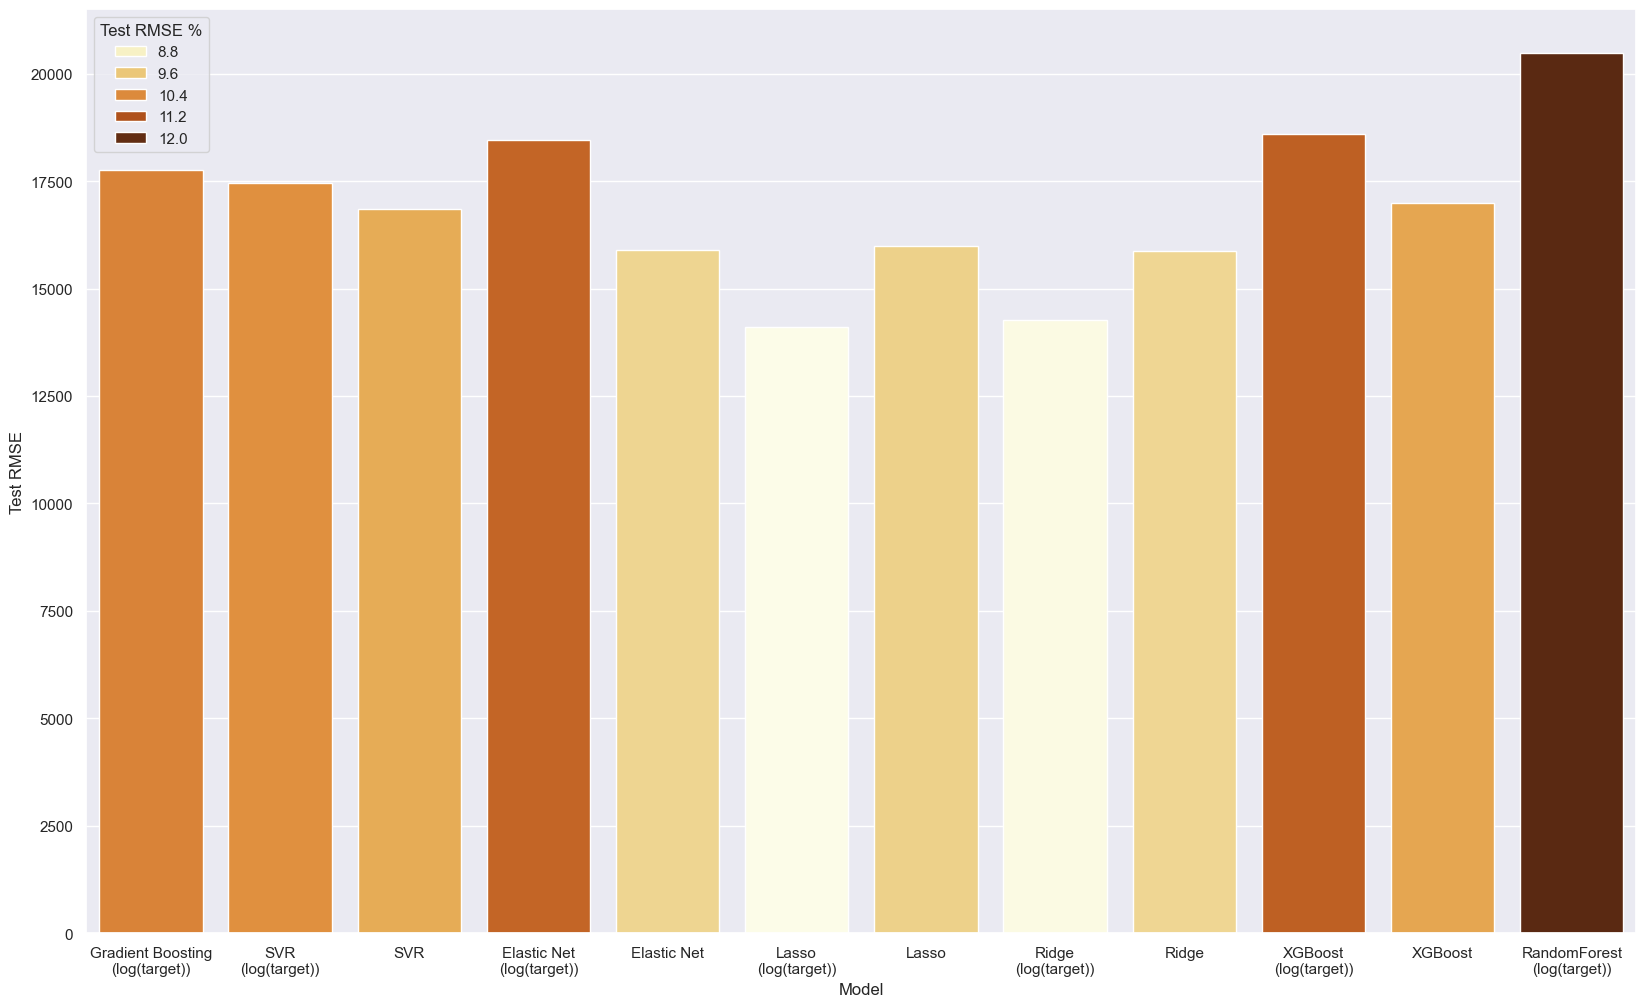

In [ ]:
results_df = pd.DataFrame(results)
sns.set_theme(rc={'figure.figsize':(20,12)})
sns.barplot(
    data=results_df,
    x="Model",
    y="Test RMSE",
    hue=results_df["Test RMSE %"],
    palette='YlOrBr',   
)



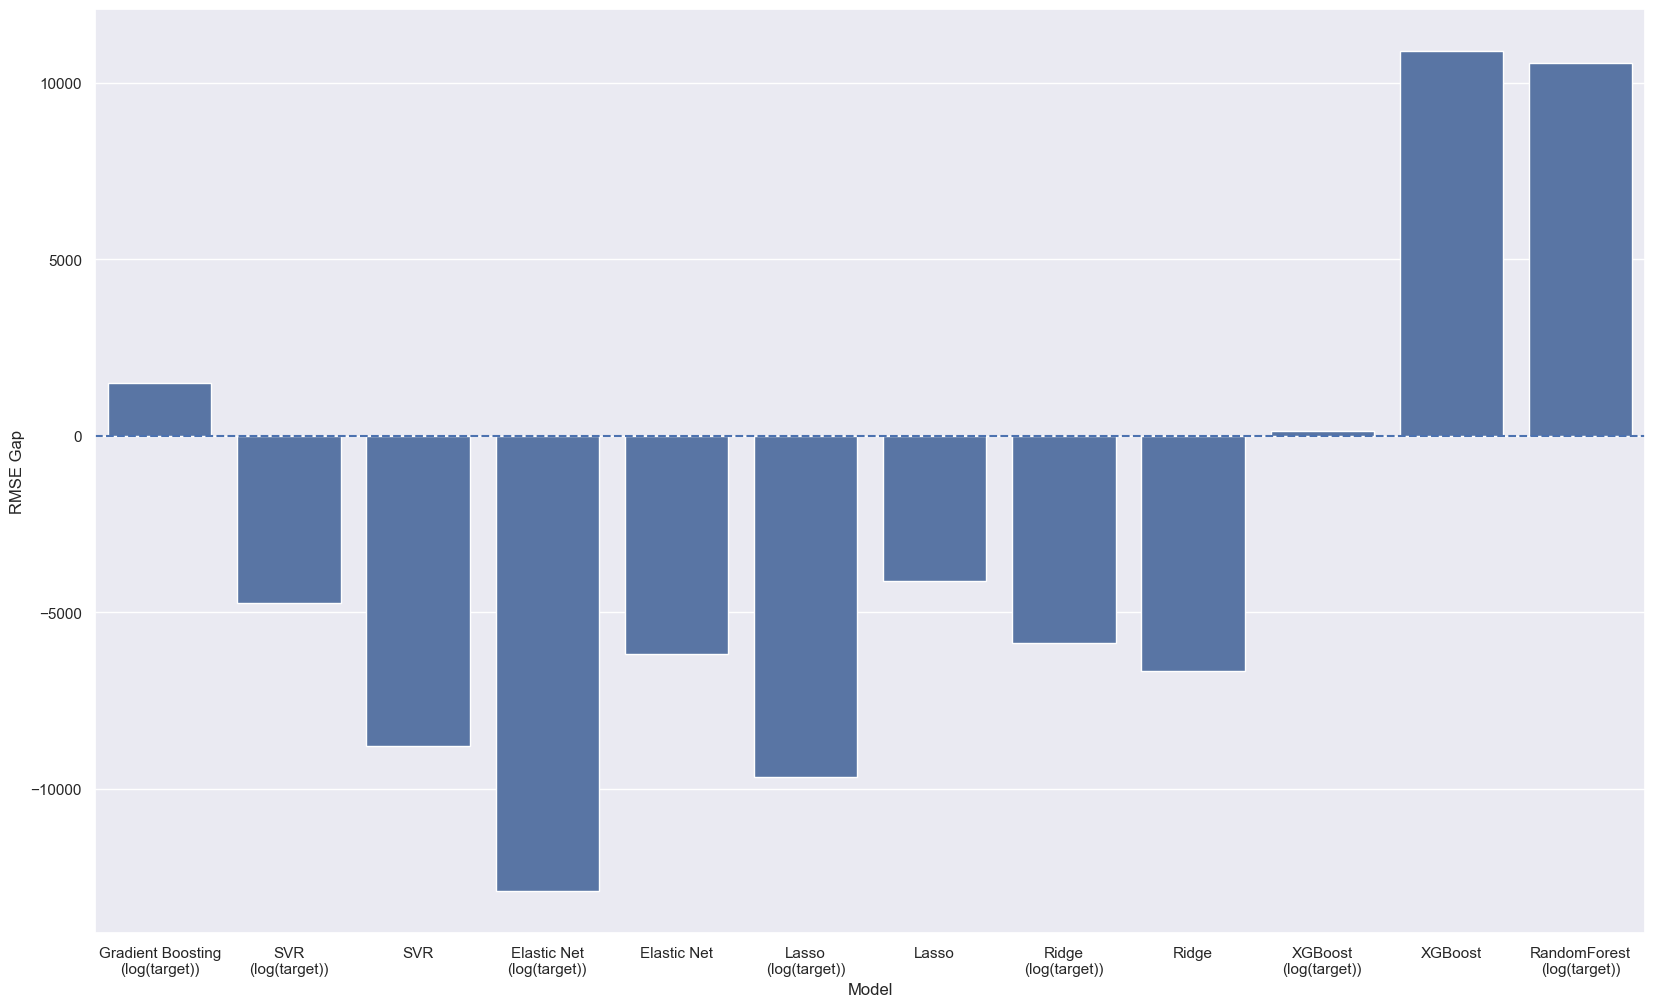

In [ ]:
ax = sns.barplot(
    data=results_df,
    x="Model",
    y="RMSE Gap"
)
ax.axhline(0, linestyle="--")


Text(0, 0.5, 'RMSE Gap (Test − Train)')

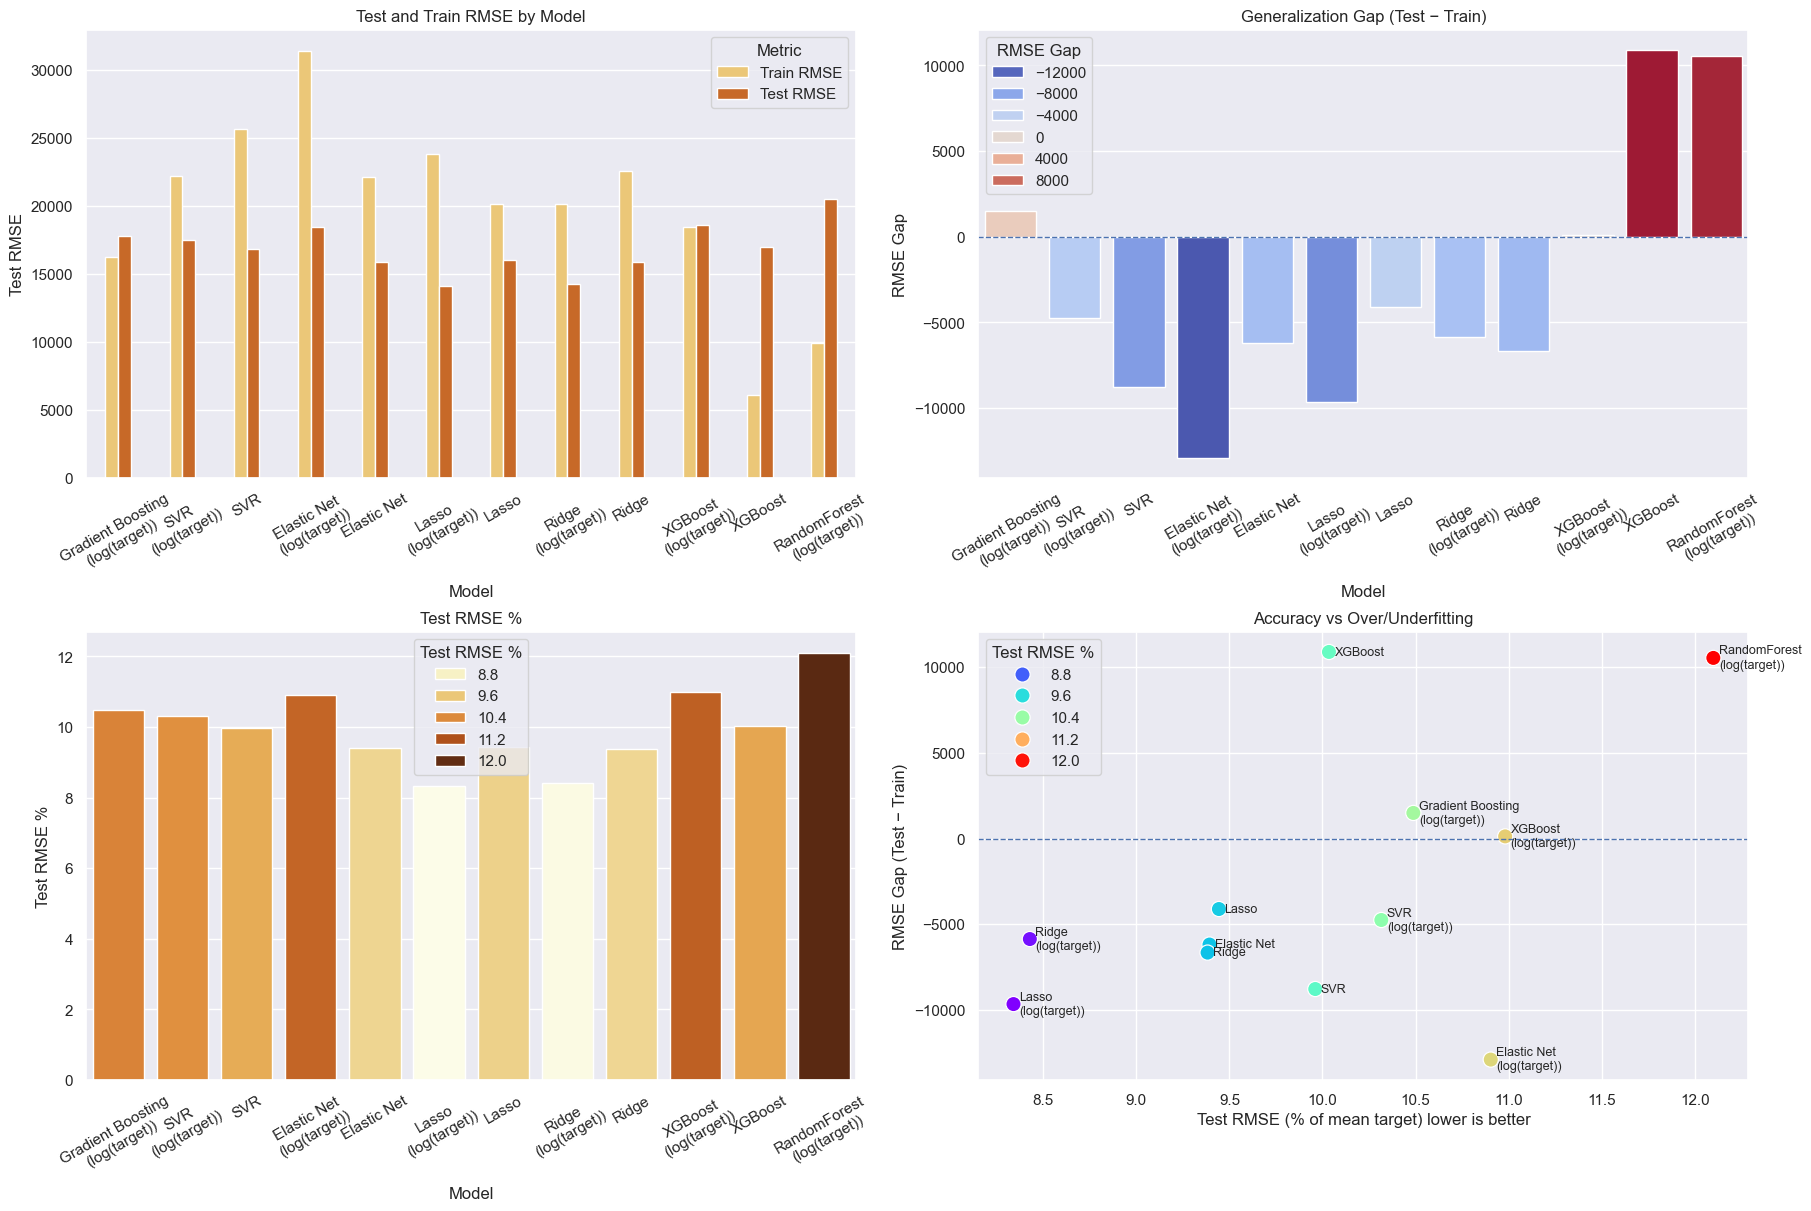

In [ ]:
fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(18, 12),
    constrained_layout=True
)

# -------------------

long_df = results_df.melt(
    id_vars="Model",
    value_vars=["Train RMSE", "Test RMSE"],
    var_name="Metric",
    value_name="RMSE",
)

sns.barplot(
    data=long_df,
    x="Model",
    y="RMSE",
    # hue=results_df["Test RMSE %"],
    hue="Metric",
    ax=axes[0,0],
    palette='YlOrBr',
    width=0.4    
)
axes[0, 0].set_title("Test and Train RMSE by Model")
axes[0, 0].set_ylabel("Test RMSE")
axes[0, 0].tick_params(axis="x", rotation=30)

# -------------------

sns.barplot(
    data=results_df,
    x="Model",
    y="RMSE Gap",
    hue="RMSE Gap",
    # palette="YlOrBr",
    palette="coolwarm",
    ax=axes[0, 1]
)
axes[0, 1].axhline(0, linestyle="--", linewidth=1)
axes[0, 1].set_title("Generalization Gap (Test − Train)")
axes[0, 1].set_ylabel("RMSE Gap")
axes[0, 1].tick_params(axis="x", rotation=30)

# --------------------

long_df = results_df.melt(
    id_vars="Model",
    value_vars=["Test RMSE %", "Test RMSE"],
    var_name="Metric",
    value_name="RMSE",
)
sns.barplot(
    data=results_df,
    x="Model",
    y="Test RMSE %",
    hue="Test RMSE %",
    ax=axes[1, 0],
    
    palette="YlOrBr"
)

axes[1, 0].set_title("Test RMSE %")
axes[1, 0].tick_params(axis="x", rotation=30)

# ----------------------

sns.scatterplot(
    data=results_df,
    x="Test RMSE %",
    y="RMSE Gap",
    hue="Test RMSE %",
    palette="rainbow",
    s=120,
    ax=axes[1, 1]
)

for _, row in results_df.iterrows():
    axes[1, 1].text(
        row["Test RMSE %"] + 0.03,
        row["RMSE Gap"],
        row["Model"],
        fontsize=9,
        verticalalignment="center"
    )

axes[1, 1].axhline(0, linestyle="--", linewidth=1)
axes[1, 1].set_title("Accuracy vs Over/Underfitting")
axes[1, 1].set_xlabel("Test RMSE (% of mean target) lower is better")
axes[1, 1].set_ylabel("RMSE Gap (Test − Train)")





In [ ]:
results

[{'Model': 'Gradient Boosting\n(log(target))',
  'Train RMSE': np.float64(16254.695245320812),
  'Test RMSE': np.float64(17750.97948711155),
  'RMSE Gap': np.float64(1496.284241790736),
  'Test RMSE %': np.float64(10.488148965173602),
  'CV RMSE': np.float64(23691.3187583149),
  'Best Params': {'regressor__model__learning_rate': np.float64(0.02575739293830275),
   'regressor__model__max_depth': 3,
   'regressor__model__max_features': np.float64(0.6432510073193155),
   'regressor__model__min_samples_split': 20,
   'regressor__model__n_estimators': 339,
   'regressor__model__subsample': 1.0,
   'regressor__selector__max_features': 108}},
 {'Model': 'SVR\n(log(target))',
  'Train RMSE': np.float64(22212.60116652813),
  'Test RMSE': np.float64(17459.877657881105),
  'RMSE Gap': np.float64(-4752.723508647025),
  'Test RMSE %': np.float64(10.316151732501446),
  'CV RMSE': np.float64(33026.85030952248),
  'Best Params': {'regressor__model__C': 0.1,
   'regressor__model__epsilon': 0.1}},
 {'Mo

## Residuals

In [ ]:
# residuals = y_test - (0.6 * lassolog_pred + 0.4 * ridgelog_pred)
lassolog_pred = best_lassolog.predict(X_test)
lasso_pred = best_lasso.predict(X_test)
ridgelog_pred = best_ridgelog.predict(X_test)
randomforest_pred = best_random_forest.predict(X_test)
xgboost_pred = best_xgboost.predict(X_test)
elasticnet_pred = best_elasticnet.predict(X_test)
svr_pred = best_svr.predict(X_test)
gradboost_pred = best_gradboost.predict(X_test)

# xgboostlog_pred = best_xgboostlog.predict(X_test)

y_pred = (
    0.6 * lassolog_pred + 
    0.4 * ridgelog_pred
)

residuals = y_test - y_pred

Text(0, 0.5, 'Residual distribution')

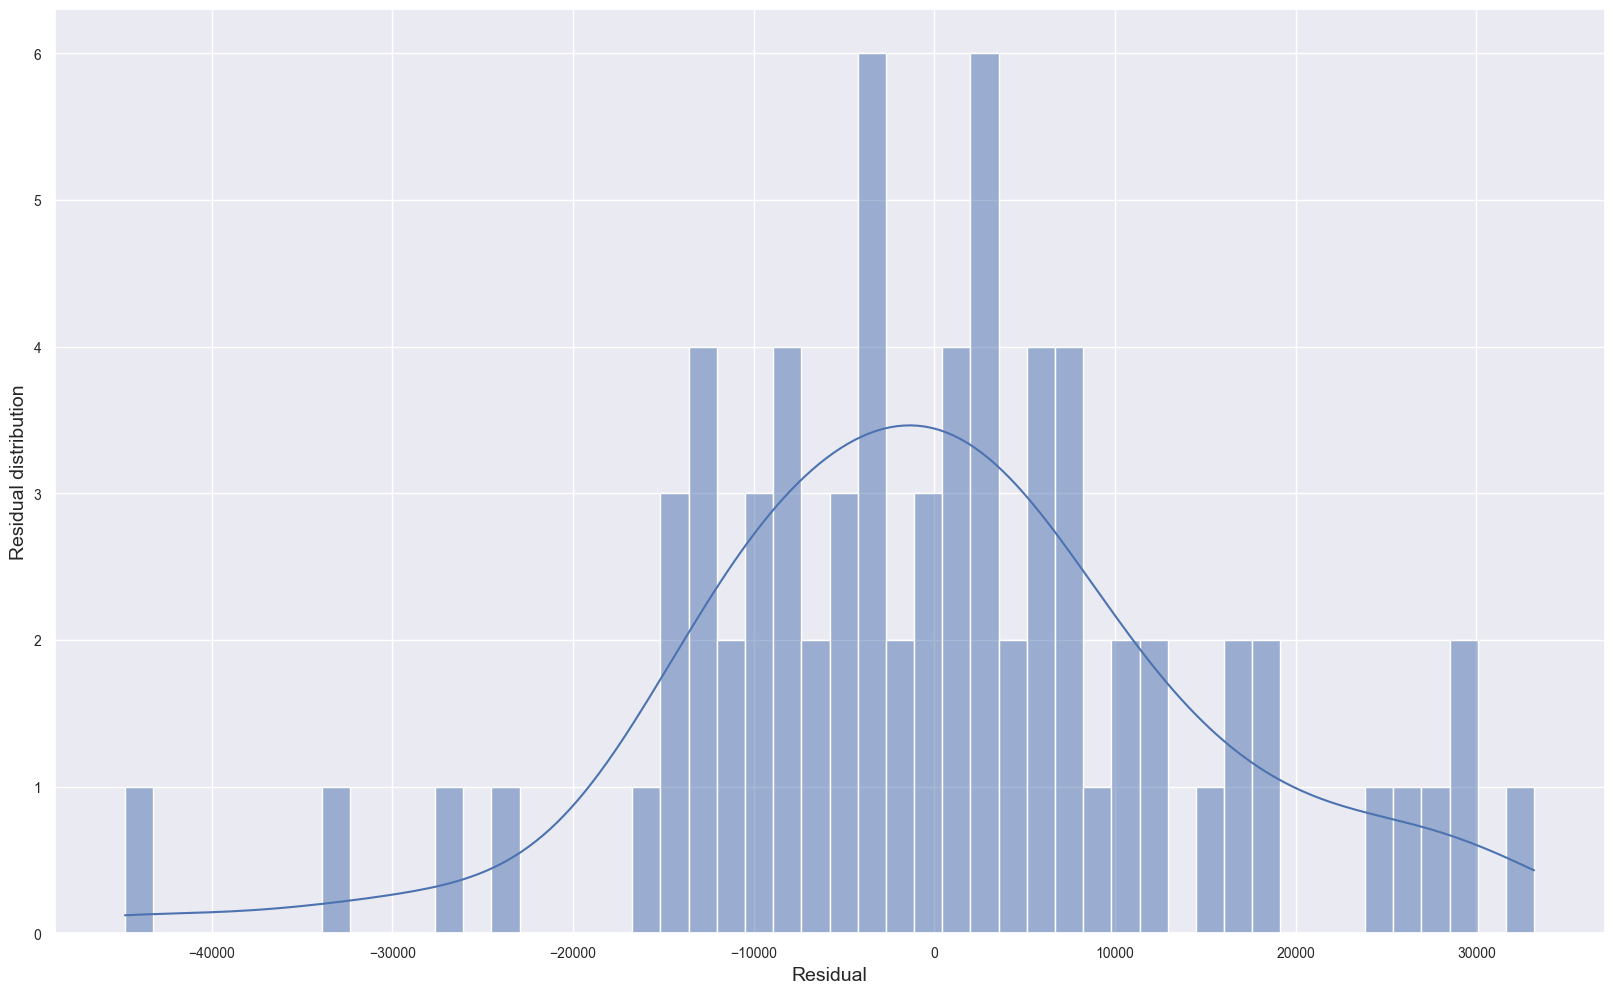

In [116]:
sns.histplot(residuals, bins=50, kde=True)
plt.xlabel('Residual')
plt.ylabel('Residual distribution')

Most of the models seem to perform pretty well for all neighborhoods except for `IDOTRR` (and to a lesser extent, `OldTown`).


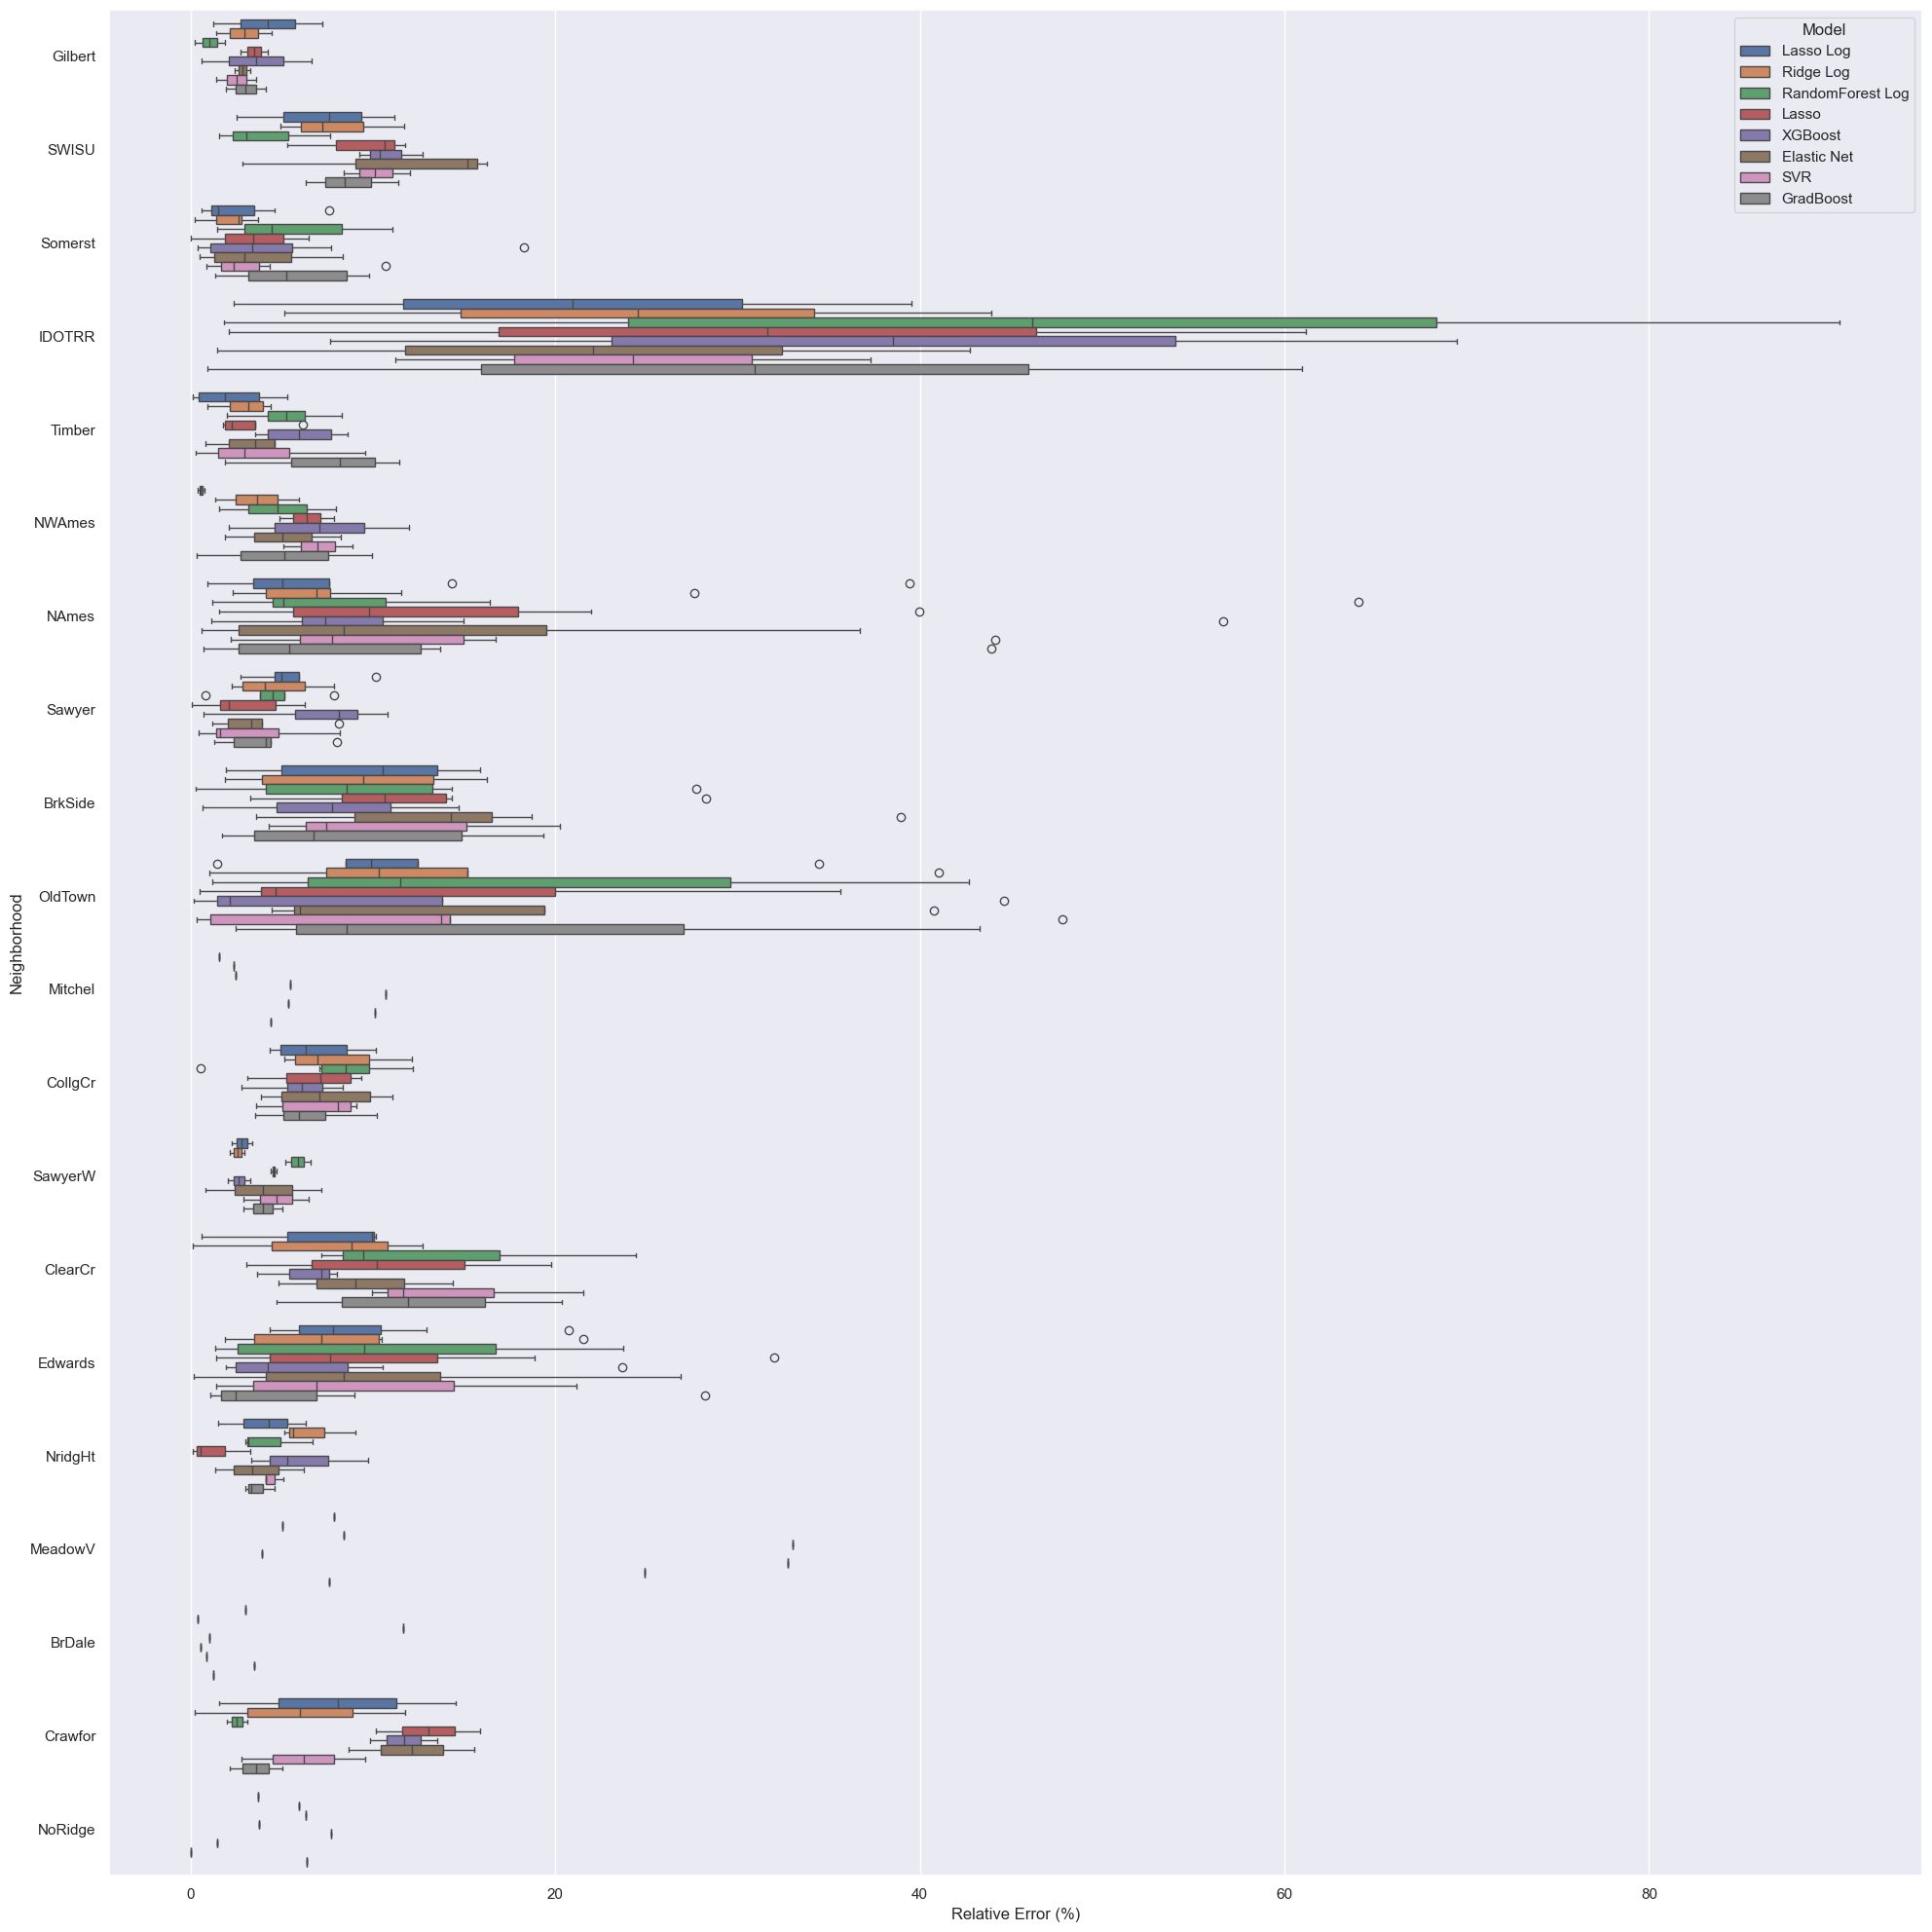

In [ ]:
lassolog_rel_error = np.abs(y_test - lassolog_pred) / y_test * 100
lasso_rel_error = np.abs(y_test - lasso_pred) / y_test * 100
ridgelog_rel_error = np.abs(y_test - ridgelog_pred) / y_test * 100
randomforest_rel_error = np.abs(y_test - randomforest_pred) / y_test * 100
xgboost_rel_error = np.abs(y_test - xgboost_pred) / y_test * 100
elasticnet_rel_error = np.abs(y_test - elasticnet_pred) / y_test * 100
svr_rel_error = np.abs(y_test - svr_pred) / y_test * 100
gradboost_rel_error = np.abs(y_test - gradboost_pred) / y_test * 100


neighborhood = X_test['Neighborhood'].values

plot_data = pd.DataFrame({
    'Neighborhood': np.tile(neighborhood, 8),  
    'Model': ['Lasso Log']*len(neighborhood) + 
             ['Ridge Log']*len(neighborhood) + 
             ['RandomForest Log']*len(neighborhood) + 
             ['Lasso']*len(neighborhood) + 
             ['XGBoost']*len(neighborhood) + 
             ['Elastic Net']*len(neighborhood) + 
             ['SVR']*len(neighborhood) +
             ['GradBoost']*len(neighborhood),
             
            'Relative_Error_%': np.concatenate([
                                         lassolog_rel_error, 
                                         ridgelog_rel_error, 
                                         randomforest_rel_error, 
                                         lasso_rel_error, 
                                         xgboost_rel_error, 
                                         elasticnet_rel_error, 
                                         svr_rel_error, 
                                         gradboost_rel_error])
})

plt.figure(figsize=(20, 20))

sns.boxplot(
    data=plot_data,
    y='Neighborhood',     
    x='Relative_Error_%', 
    hue='Model',          
    orient='h',           

)

plt.xlabel('Relative Error (%)')
plt.tight_layout()
plt.show()

However the absolute error for those two neighborhoods isn't that high, and they are some of the cheapest neighborhoods (small absolute errors can still be very significant), so I'm not sure these predictions can be that much more accurate without more data.

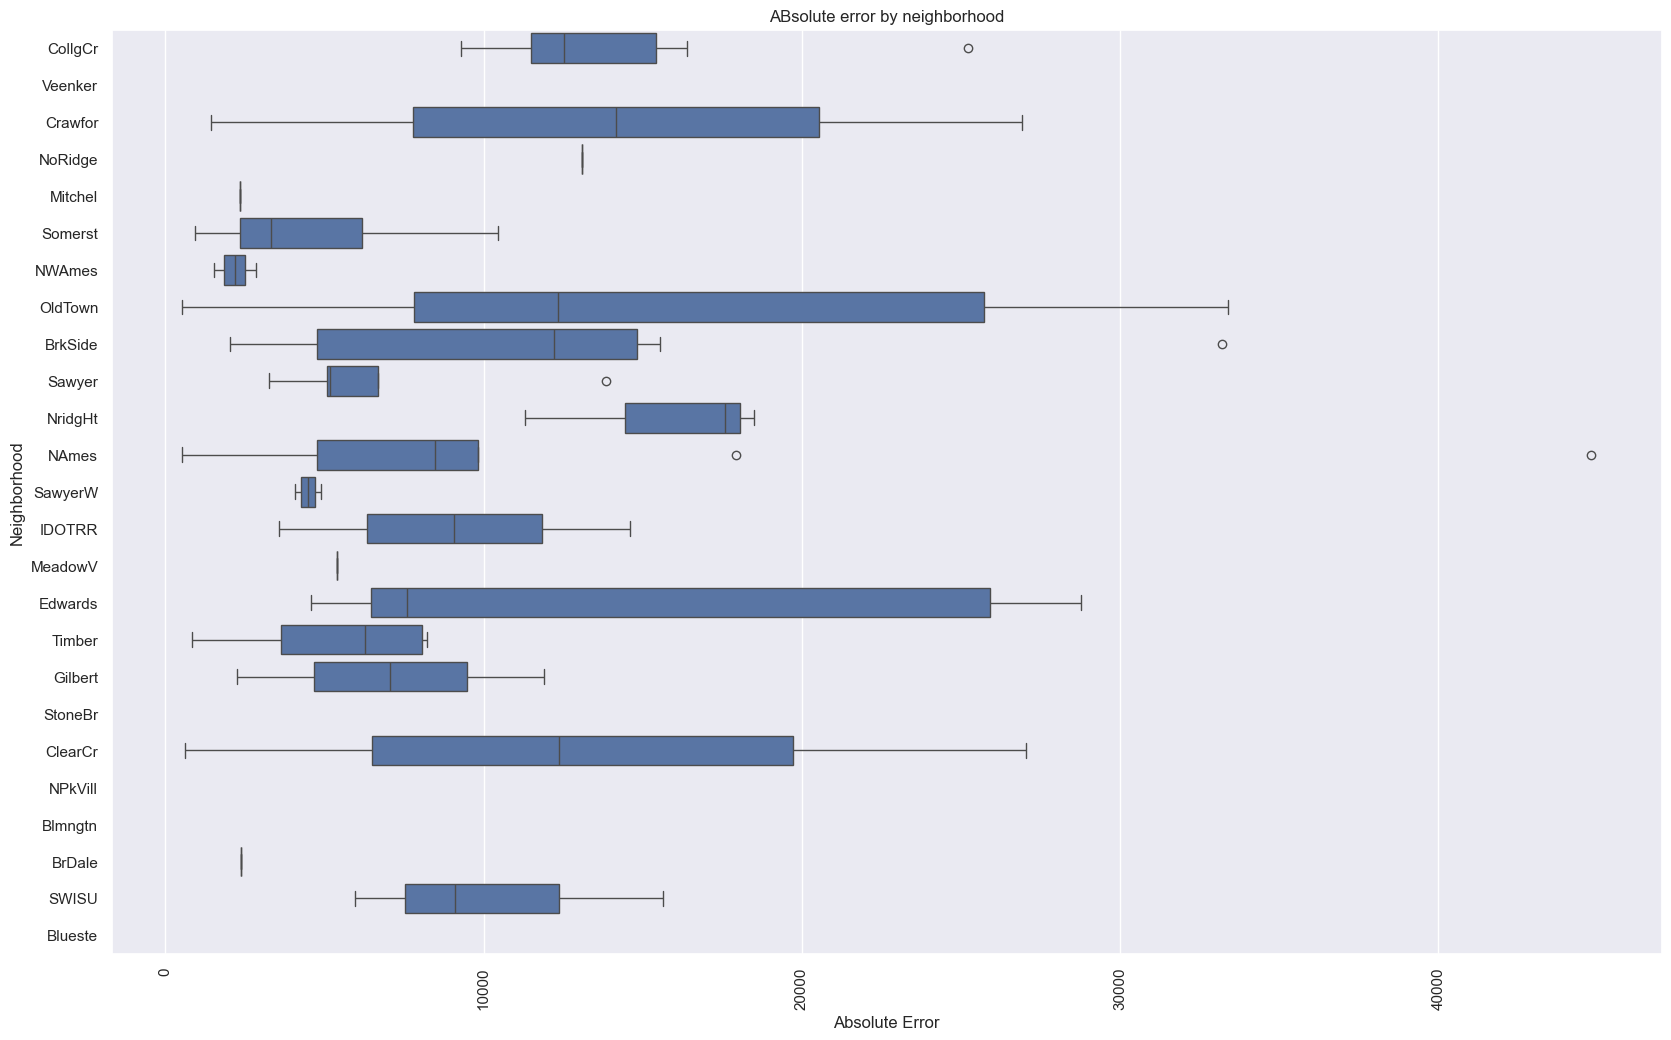

In [92]:
df = housing_full.copy()

df['abs_error'] = np.abs(residuals)

sns.boxplot(
    x="abs_error",
    y="Neighborhood",
    data=df,
    orient='h'
)

plt.xlabel("Absolute Error")
plt.ylabel("Neighborhood")
plt.xticks(rotation=90)
plt.title("ABsolute error by neighborhood")
plt.show()

<Figure size 2000x2000 with 0 Axes>

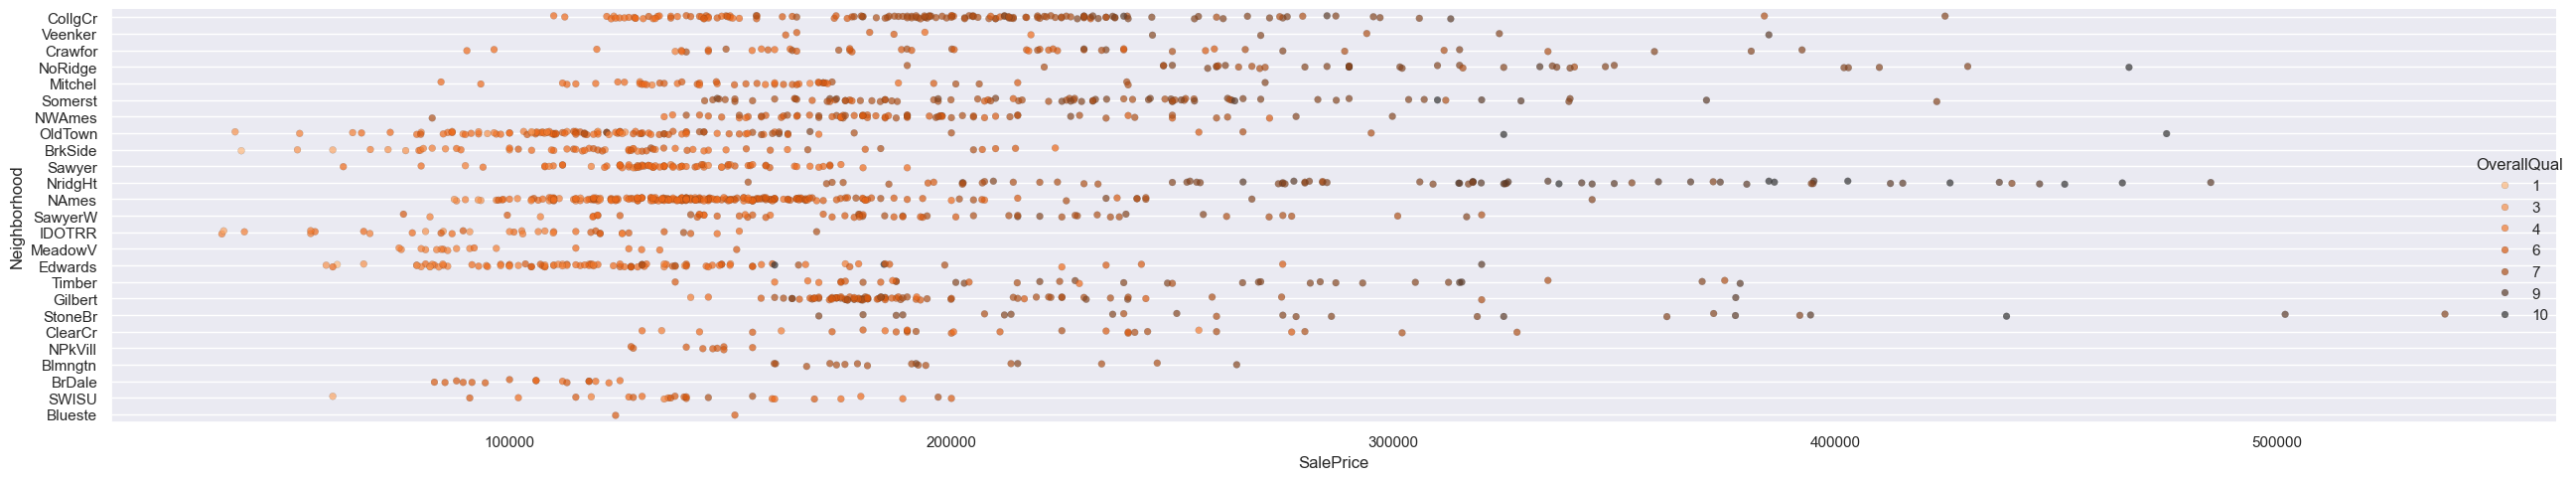

In [89]:
plt.figure(figsize=(20, 20))
sns.catplot(y = df['Neighborhood'] ,x = df['SalePrice'], hue = df['OverallQual'], palette="Oranges_d", linewidth=0.1, alpha=0.7, aspect=5)
plt.tight_layout()
plt.grid()
plt.show()



In [73]:
housing_full["Neighborhood"].value_counts()


Neighborhood
NAmes      225
CollgCr    150
OldTown    113
Edwards    100
Somerst     86
Gilbert     79
Sawyer      74
NridgHt     74
NWAmes      73
SawyerW     59
BrkSide     58
Crawfor     51
Mitchel     49
NoRidge     38
Timber      38
IDOTRR      37
ClearCr     28
SWISU       25
StoneBr     24
MeadowV     17
Blmngtn     17
BrDale      16
Veenker     11
NPkVill      9
Blueste      2
Name: count, dtype: int64

# Making Predictions

In [238]:
test_data = load_data('test.csv')

In [ ]:
test_data = prepare_data(df=test_data, 
                            corr_threshold=0.0,
                            outliers_threshold=0.0, 
                            remove_inconsistent_rows=False,                         
                            verbose=True)

test_ids = test_data['Id'].copy()


X_submission = test_data.copy()

# X_test = test_data.drop('Id', axis=1)
X_submission = X_submission[X.columns]



Numerical features: 37
Categorical features: 43


In [ ]:
gradboost_pred = best_gradboost.predict(X_submission)
lassolog_pred = best_lassolog.predict(X_submission)
ridgelog_pred = best_ridgelog.predict(X_submission)
xgboost_pred = best_xgboost.predict(X_submission)
xgboostlog_pred = best_xgboostlog.predict(X_submission)

ensemble_predictions = (
    0.6 * lassolog_pred+
  0.4 * ridgelog_pred 
) 

submission = pd.DataFrame({
    'Id': test_ids,
    'SalePrice': ensemble_predictions
})

submission.to_csv('submission.csv', index=False)
print(f"\nSubmission file created with {len(submission)} predictions")


Submission file created with 1459 predictions
